In [1]:
# 🔧 재현성 보장: 전역 시드 고정 (1/3)
print("🎯 재현성 확보를 위한 전역 시드 고정 중...")

import random
import numpy as np
import torch

# 시드 고정
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # GPU 사용 시
torch.backends.cudnn.deterministic = True  # ⚠️ 주의: 속도 감소 가능
torch.backends.cudnn.benchmark = False  # 성능 최적화 비활성화 (재현성 우선)

print(f"✅ 전역 시드 {seed}로 고정 완료 (CPU/GPU 모두 포함)")
print("   🎯 random, numpy, torch, cuda 모든 난수 생성기 동기화")
print("   ⚠️  속도 감소 가능하지만 완전한 재현성 보장")


🎯 재현성 확보를 위한 전역 시드 고정 중...
✅ 전역 시드 42로 고정 완료 (CPU/GPU 모두 포함)
   🎯 random, numpy, torch, cuda 모든 난수 생성기 동기화
   ⚠️  속도 감소 가능하지만 완전한 재현성 보장


In [2]:
# JSON 안전 변환 함수 추가 (타입 변환 문제 해결)
def safe_json_convert(obj):
    """JSON 직렬화를 위한 안전한 타입 변환
    
    문제 해결:
    - NumPy 타입 (np.float32, np.int64 등) → Python 기본 타입
    - NaN, Infinity 값 → 안전한 값/문자열
    - Tensor 객체 → NumPy 배열 → 리스트
    """
    import numpy as np
    import torch
    
    if obj is None:
        return None
    elif isinstance(obj, (np.integer, np.int8, np.int16, np.int32, np.int64)):
        return int(obj)  # NumPy 정수 → Python int
    elif isinstance(obj, (np.floating, np.float16, np.float32, np.float64)):
        # NaN, Inf 처리
        if np.isnan(obj):
            return None  # 또는 "NaN"
        elif np.isinf(obj):
            return "Infinity" if obj > 0 else "-Infinity"
        else:
            return float(obj)  # NumPy float → Python float
    elif isinstance(obj, np.ndarray):
        return [safe_json_convert(item) for item in obj.tolist()]
    elif isinstance(obj, torch.Tensor):
        return safe_json_convert(obj.detach().cpu().numpy())
    elif isinstance(obj, (list, tuple)):
        return [safe_json_convert(item) for item in obj]
    elif isinstance(obj, dict):
        return {key: safe_json_convert(value) for key, value in obj.items()}
    elif isinstance(obj, str):
        return obj
    elif isinstance(obj, (int, float, bool)):
        # 기본 Python 타입 확인
        if isinstance(obj, float):
            if np.isnan(obj):
                return None
            elif np.isinf(obj):
                return "Infinity" if obj > 0 else "-Infinity"
        return obj
    else:
        # 직렬화할 수 없는 객체는 문자열로 변환
        try:
            return str(obj)
        except:
            return f"<{type(obj).__name__}>"

print("✅ JSON 안전 변환 함수 정의 완료")
print("   🔧 NumPy 타입 → Python 기본 타입 변환")
print("   🔧 NaN/Infinity 값 안전 처리")
print("   🔧 Tensor 객체 자동 변환")


✅ JSON 안전 변환 함수 정의 완료
   🔧 NumPy 타입 → Python 기본 타입 변환
   🔧 NaN/Infinity 값 안전 처리
   🔧 Tensor 객체 자동 변환


In [3]:
# 🚀 Enhanced β-VAE 통합 임베딩 시스템
# 기존 unified_beta_vae.ipynb + 7가지 핵심 개선사항 통합
# 1. Enhanced Loss Function 2. KL Annealing 3. Latent Visualization 
# 4. Cosine Monitoring 5. Recall@K 6. Band-Specific Models 7. Comprehensive Evaluation

# OpenMP 충돌 문제 해결 (Intel OpenMP와 LLVM OpenMP 충돌 방지)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'  # Intel OpenMP 중복 로딩 허용

# threadpoolctl 경고 무시 (OpenMP 충돌 관련)
import warnings
warnings.filterwarnings('ignore', message='.*Intel OpenMP.*', category=RuntimeWarning)
warnings.filterwarnings('ignore', message='.*threadpoolctl.*', category=RuntimeWarning)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.cuda.amp import GradScaler, autocast
import numpy as np
import pandas as pd
import psycopg2
import json
from datetime import datetime
import logging
from tqdm import tqdm
import os
import math
import copy
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import umap

# 한글 폰트 설정 - 자동으로 시스템의 한글 폰트 찾아서 설정
try:
    # 프로젝트 루트 경로 추가
    import sys
    import os
    if '..' not in sys.path:
        sys.path.append('..')
    
    from core.pipeline.font_utils import setup_korean_font
    
    # 한글 폰트 자동 설정
    selected_font = setup_korean_font()
    if selected_font:
        print(f"✅ 한글 폰트 설정 완료: {selected_font}")
    else:
        print("⚠️ 한글 폰트를 찾을 수 없어 기본 설정을 사용합니다.")
        # 기본 설정으로 fallback
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['axes.unicode_minus'] = False
        
except ImportError as e:
    print(f"⚠️ 한글 폰트 유틸리티 로드 실패: {e}")
    # 수동 폰트 설정
    import matplotlib.font_manager as fm
    
    # Windows에서 일반적으로 사용 가능한 한글 폰트들
    korean_fonts = ['Malgun Gothic', 'Batang', 'Dotum', 'Gulim']
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    selected_font = None
    for font in korean_fonts:
        if font in available_fonts:
            selected_font = font
            break
    
    if selected_font:
        plt.rcParams['font.family'] = selected_font
        print(f"✅ 수동 한글 폰트 설정: {selected_font}")
    else:
        plt.rcParams['font.family'] = 'sans-serif'
        print("⚠️ 한글 폰트 없음 - 기본 폰트 사용")
    
    plt.rcParams['axes.unicode_minus'] = False

# FAISS 임포트 (선택적)
try:
    import faiss
    FAISS_AVAILABLE = True
except ImportError:
    FAISS_AVAILABLE = False
    print("   ⚠️ FAISS 라이브러리가 없어 sklearn 기반으로 대체 구현")

# 로깅 설정
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

print("=" * 80)
print("🚀 Enhanced β-VAE 통합 임베딩 파이프라인 시작")
print("🔥 7가지 핵심 개선사항 + 실제 DB 연동 + 완전 자동화")
print("💡 Enhanced Loss | KL Annealing | Latent Viz | Cosine Monitor")
print("🔍 Recall@K | Band-Specific | Comprehensive Eval")
print("=" * 80)

# GPU 설정 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🎯 사용 디바이스: {device}")
if torch.cuda.is_available():
    print(f"   🔸 GPU: {torch.cuda.get_device_name()}")
    print(f"   🔸 GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"   🔸 CUDA 버전: {torch.version.cuda}")
else:
    print("   ⚠️ CUDA를 사용할 수 없습니다. CPU로 훈련합니다.")

logger.info(f"Enhanced β-VAE 시스템 초기화 완료: {device}")


2025-06-27 01:37:52,749 - INFO - Enhanced β-VAE 시스템 초기화 완료: cuda


⚠️ 한글 폰트 유틸리티 로드 실패: No module named 'core.pipeline.font_utils'
✅ 수동 한글 폰트 설정: Malgun Gothic
🚀 Enhanced β-VAE 통합 임베딩 파이프라인 시작
🔥 7가지 핵심 개선사항 + 실제 DB 연동 + 완전 자동화
💡 Enhanced Loss | KL Annealing | Latent Viz | Cosine Monitor
🔍 Recall@K | Band-Specific | Comprehensive Eval
🎯 사용 디바이스: cuda
   🔸 GPU: NVIDIA GeForce GTX 1080 Ti
   🔸 GPU 메모리: 11.0 GB
   🔸 CUDA 버전: 12.1


In [4]:
# 🔍 Origin Vector 테이블 상태 진단
print("\n🔍 Origin Vector 테이블 상태 진단")
print("-" * 60)

# 1. 테이블 존재 여부 확인
try:
    cursor.execute("SELECT COUNT(*) FROM origin_vector")
    total_count = cursor.fetchone()[0]
    print(f"✅ origin_vector 테이블 총 레코드 수: {total_count:,}개")
except Exception as e:
    print(f"❌ origin_vector 테이블 접근 실패: {e}")

# 2. vector_type 값들 확인
try:
    cursor.execute("SELECT vector_type, COUNT(*) FROM origin_vector GROUP BY vector_type")
    vector_types = cursor.fetchall()
    print(f"\n📊 vector_type별 분포:")
    for vtype, count in vector_types:
        print(f"   🔸 '{vtype}': {count:,}개")
except Exception as e:
    print(f"❌ vector_type 조회 실패: {e}")

# 3. embedding 필드 상태 확인
try:
    cursor.execute("SELECT COUNT(*) FROM origin_vector WHERE embedding IS NOT NULL")
    embedding_count = cursor.fetchone()[0]
    print(f"\n📊 embedding 필드:")
    print(f"   🔸 embedding IS NOT NULL: {embedding_count:,}개")
    print(f"   🔸 embedding IS NULL: {total_count - embedding_count:,}개")
except Exception as e:
    print(f"❌ embedding 상태 조회 실패: {e}")

# 4. 샘플 데이터 확인 (처음 5개)
try:
    cursor.execute("""
        SELECT id, image_path, vector_type, 
               CASE WHEN embedding IS NOT NULL THEN 'NOT NULL' ELSE 'NULL' END as embedding_status
        FROM origin_vector 
        ORDER BY id 
        LIMIT 5
    """)
    samples = cursor.fetchall()
    print(f"\n📋 샘플 데이터 (처음 5개):")
    for sample in samples:
        print(f"   🔸 ID: {sample[0]}, Path: {sample[1]}, Type: {sample[2]}, Embedding: {sample[3]}")
except Exception as e:
    print(f"❌ 샘플 데이터 조회 실패: {e}")

# 5. ArcFace 타입 정확한 값 확인
try:
    cursor.execute("SELECT DISTINCT vector_type FROM origin_vector WHERE vector_type ILIKE '%arc%'")
    arc_types = cursor.fetchall()
    print(f"\n🔍 'arc' 포함 vector_type:")
    for arc_type in arc_types:
        print(f"   🔸 '{arc_type[0]}'")
except Exception as e:
    print(f"❌ ArcFace 타입 조회 실패: {e}")

print("\n" + "="*60)



🔍 Origin Vector 테이블 상태 진단
------------------------------------------------------------
❌ origin_vector 테이블 접근 실패: name 'cursor' is not defined
❌ vector_type 조회 실패: name 'cursor' is not defined
❌ embedding 상태 조회 실패: name 'cursor' is not defined
❌ 샘플 데이터 조회 실패: name 'cursor' is not defined
❌ ArcFace 타입 조회 실패: name 'cursor' is not defined



In [5]:
# 🗑️ 중복 셀 제거됨 
# 이 셀의 기능은 Cell 4(데이터 로딩)에 통합되었습니다.
print("💡 중복 제거 완료: 모든 데이터 로딩 기능이 Cell 4에 통합되었습니다.")


💡 중복 제거 완료: 모든 데이터 로딩 기능이 Cell 4에 통합되었습니다.


In [6]:
# 📊 1단계: 데이터베이스 연결 및 데이터 로딩
print("\n📊 1단계: 데이터베이스 연결 및 데이터 로딩")
print("-" * 60)

# DB 연결
try:
    logger.info("PostgreSQL 데이터베이스 연결 시도 중...")
    conn = psycopg2.connect(
        dbname='postgres', user='postgres', password='postgres', host='localhost', port=5432
    )
    cursor = conn.cursor()
    logger.info("✅ 데이터베이스 연결 성공")
    print("✅ 데이터베이스 연결 완료")
except Exception as e:
    logger.error(f"❌ 데이터베이스 연결 실패: {e}")
    raise

# 데이터 로딩 함수
def load_vectors(table_name: str, dim_limit: int = 512):
    """실제 DB에서 벡터 로딩 - 🔧 재현성 보장: DB 쿼리 정렬 추가 (2/3)"""
    logger.info(f"테이블 '{table_name}'에서 벡터 로딩 시작 (차원 제한: 128-{dim_limit})")
    query = f"""
        SELECT embedding FROM {table_name}
        WHERE embedding IS NOT NULL AND compressed_dim BETWEEN 128 AND {dim_limit}
          AND compression_ratio <= 1.0
        ORDER BY origin_vector_id, id
    """
    cursor.execute(query)
    rows = cursor.fetchall()
    logger.info(f"쿼리 실행 완료: {len(rows)}개 레코드 발견 (origin_vector_id, id 정렬)")
    
    print(f"   📁 {table_name} 테이블에서 벡터 파싱 중...")
    vectors = []
    for i, row in enumerate(tqdm(rows, desc=f"   {table_name} 파싱", leave=False)):
        try:
            vectors.append(np.array(json.loads(row[0])))
        except Exception as e:
            logger.warning(f"벡터 파싱 실패 (행 {i}): {e}")
    
    logger.info(f"✅ '{table_name}' 로딩 완료: {len(vectors)}개 벡터")
    return vectors

def load_origin_vectors_with_paths():
    """Origin vector 테이블에서 ArcFace 벡터와 image_path 로딩 (수정된 버전)
    
    수정사항: vector_type을 'origin'으로 검색 + 🔧 재현성 보장: 정렬 추가
    """
    logger.info("origin_vector 테이블에서 ArcFace teacher 벡터 로딩 시작")
    query = """
        SELECT image_path, embedding 
        FROM origin_vector 
        WHERE embedding IS NOT NULL AND vector_type = 'origin'
        ORDER BY id, image_path
    """
    cursor.execute(query)
    rows = cursor.fetchall()
    logger.info(f"쿼리 실행 완료: {len(rows)}개 ArcFace 벡터 발견 (id, image_path 정렬)")
    
    print(f"   📁 origin_vector 테이블에서 ArcFace 벡터 파싱 중...")
    image_paths = []
    origin_vectors = []
    
    for i, (image_path, embedding) in enumerate(tqdm(rows, desc="   ArcFace 벡터 파싱", leave=False)):
        try:
            # PostgreSQL vector 타입을 numpy 배열로 변환
            if isinstance(embedding, str):
                # 문자열 형태의 벡터를 파싱
                vector_str = embedding.strip('[]')
                vector_array = np.array([float(x) for x in vector_str.split(',')])
            else:
                # 이미 배열 형태인 경우
                vector_array = np.array(embedding)
            
            image_paths.append(image_path)
            origin_vectors.append(vector_array)
        except Exception as e:
            logger.warning(f"ArcFace 벡터 파싱 실패 (행 {i}): {e}")
    
    logger.info(f"✅ ArcFace origin 벡터 로딩 완료: {len(origin_vectors)}개 벡터 (512D)")
    return image_paths, origin_vectors

print("📥 Wavelet 벡터 로딩 중...")
wavelet_vectors = load_vectors('wavelet_vector')

print("📥 DCT 벡터 로딩 중...")
dct_vectors = load_vectors('dct_vector')

print("📥 ArcFace Origin 벡터 로딩 중...")
origin_image_paths, origin_vectors = load_origin_vectors_with_paths()

print("\n📊 데이터 통합 및 분석 중...")
all_vectors = wavelet_vectors + dct_vectors
original_dims = [len(vec) for vec in all_vectors]
max_dim = max(original_dims) if original_dims else 0

# Origin 벡터는 512차원이므로 max_dim 업데이트
origin_dim = len(origin_vectors[0]) if origin_vectors else 0
max_dim = max(max_dim, origin_dim)

print("\n📈 데이터 요약:")
print(f"   🔸 Wavelet 벡터: {len(wavelet_vectors):,}개")
print(f"   🔸 DCT 벡터: {len(dct_vectors):,}개")
print(f"   🔸 ArcFace Origin 벡터: {len(origin_vectors):,}개 ({origin_dim}D)")
print(f"   🔸 총 입력 벡터 수: {len(all_vectors):,}개")
print(f"   🔸 최대 차원: {max_dim}")

# 벡터 패딩 및 텐서 변환
logger.info(f"벡터 패딩 시작: 목표 차원 {max_dim}")
print(f"\n📐 모든 벡터를 {max_dim} 차원으로 패딩 중...")

padded_vectors = []
for i, vec in enumerate(tqdm(all_vectors, desc="   벡터 패딩", leave=False)):
    try:
        padded_vec = np.pad(vec, (0, max_dim - len(vec)))
        padded_vectors.append(padded_vec)
    except Exception as e:
        logger.error(f"벡터 패딩 실패 (인덱스 {i}): {e}")
        raise

X = torch.tensor(padded_vectors, dtype=torch.float32)  # CPU에 유지

print(f"\n📊 텐서 정보:")
print(f"   🔸 패딩된 벡터 모양: {X.shape}")
print(f"   🔸 데이터 타입: {X.dtype}")
print(f"   🔸 메모리 사용량: {X.element_size() * X.nelement() / 1024**2:.2f} MB")

# Origin 벡터 처리
print(f"\n📐 Origin 벡터를 {max_dim} 차원으로 패딩 중...")

if origin_vectors:
    # 실제 Origin 벡터가 있는 경우
    padded_origin_vectors = []
    for vec in tqdm(origin_vectors, desc="   Origin 벡터 패딩", leave=False):
        if len(vec) < max_dim:
            padded_vec = np.pad(vec, (0, max_dim - len(vec)))
        else:
            padded_vec = vec[:max_dim]  # 필요시 차원 축소
        padded_origin_vectors.append(padded_vec)
    
    Origin_X = torch.tensor(padded_origin_vectors, dtype=torch.float32)
    print(f"   ✅ 실제 Origin 벡터 {len(origin_vectors):,}개 사용")
    
else:
    # Origin 벡터가 없는 경우 더미 벡터 생성
    logger.warning("⚠️ Origin 벡터가 없습니다. 더미 벡터를 생성합니다.")
    print("⚠️ Origin 벡터가 없습니다. 더미 벡터를 생성합니다.")
    
    dummy_origin_count = min(1000, len(X) // 10)  # 전체 데이터의 10% 또는 최대 1000개
    padded_origin_vectors = []
    for _ in range(dummy_origin_count):
        dummy_vec = np.random.normal(0, 0.1, max_dim)  # 작은 분산으로 더미 벡터 생성
        padded_origin_vectors.append(dummy_vec)
    
    Origin_X = torch.tensor(padded_origin_vectors, dtype=torch.float32)
    origin_image_paths = [f"dummy_path_{i}.jpg" for i in range(dummy_origin_count)]
    logger.info(f"더미 Origin 벡터 {dummy_origin_count}개 생성 완료")
    print(f"   🔧 더미 Origin 벡터 {dummy_origin_count}개 생성 완료")

print(f"\n📊 Origin 벡터 텐서 정보:")
print(f"   🔸 Origin 벡터 모양: {Origin_X.shape}")
print(f"   🔸 메모리 사용량: {Origin_X.element_size() * Origin_X.nelement() / 1024**2:.2f} MB")

# 🔧 개선사항 1+2: train/val 독립적 origin_indices 생성 및 무결성 검증
print(f"\n🔄 개선된 훈련/검증 데이터 분할 중...")

# 먼저 데이터 분할 (origin 매핑 전)
n_samples = len(X)
indices = np.arange(n_samples)
train_indices, val_indices = train_test_split(
    indices, test_size=0.1, random_state=42, shuffle=True
)

print(f"   🔸 전체 데이터: {n_samples:,}개")
print(f"   🔸 훈련 데이터: {len(train_indices):,}개 ({len(train_indices)/n_samples*100:.1f}%)")
print(f"   🔸 검증 데이터: {len(val_indices):,}개 ({len(val_indices)/n_samples*100:.1f}%)")

# 🔧 개선사항 1: train/val에서 독립적으로 origin_indices 생성 + 🔧 재현성 보장: 결정적 매핑 (3/3)
print(f"\n🔗 개선된 Origin 벡터 매핑 생성 (데이터 누수 방지 + 결정적 매핑) 중...")
n_origin_samples = len(Origin_X)

# 🎯 결정적 매핑: 시드가 고정된 RNG 사용
rng = np.random.default_rng(seed=42)

# 훈련용 origin 매핑 (독립적 + 결정적)
train_origin_indices = np.tile(np.arange(n_origin_samples), 
                             (len(train_indices) // n_origin_samples + 1))[:len(train_indices)]
rng.shuffle(train_origin_indices)  # 시드 고정된 RNG로 셔플

# 검증용 origin 매핑 (독립적 + 결정적)
val_origin_indices = np.tile(np.arange(n_origin_samples), 
                           (len(val_indices) // n_origin_samples + 1))[:len(val_indices)]
rng.shuffle(val_origin_indices)  # 동일한 RNG로 셔플

# 🔧 개선사항 2: origin_indices 무결성 검증

print(f"\n🎯 재현성 보장 완료 - 3가지 핵심 문제 해결:")
print(f"   ✅ 1/3: 전역 시드 고정 (seed={seed}) - 모든 난수 요소 동기화")
print(f"   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id")
print(f"   ✅ 3/3: 결정적 origin 매핑 - 시드 고정된 RNG 사용")
print(f"   🎯 결과: 동일 파라미터 → 동일 로그, 동일 최종 성능 보장")
print(f"   🔍 Origin 인덱스 무결성 검증 중...")

# 인덱스 범위 검증
assert len(train_origin_indices) == len(train_indices), f"훈련 매핑 길이 불일치: {len(train_origin_indices)} != {len(train_indices)}"
assert len(val_origin_indices) == len(val_indices), f"검증 매핑 길이 불일치: {len(val_origin_indices)} != {len(val_indices)}"
assert all(0 <= idx < n_origin_samples for idx in train_origin_indices), "훈련 origin 인덱스 범위 오류"
assert all(0 <= idx < n_origin_samples for idx in val_origin_indices), "검증 origin 인덱스 범위 오류"

print(f"   ✅ 무결성 검증 완료: 모든 인덱스가 유효 범위 [0, {n_origin_samples-1}] 내에 있음")
print(f"   🔸 매핑 방식: 독립적 순환 반복 + 랜덤 셔플 (데이터 누수 방지)")
print(f"   🔸 훈련 벡터 {len(train_indices):,}개 → Origin 벡터 {n_origin_samples:,}개")
print(f"   🔸 검증 벡터 {len(val_indices):,}개 → Origin 벡터 {n_origin_samples:,}개")

# 커스텀 데이터셋 클래스 정의 (입력 벡터 + Origin 벡터 쌍 반환)
class VAEOriginDataset(data.Dataset):
    """VAE 입력 벡터와 ArcFace Origin 벡터를 쌍으로 제공하는 데이터셋"""
    def __init__(self, input_vectors, origin_vectors, origin_indices):
        """
        Args:
            input_vectors: (N, input_dim) 입력 벡터 텐서
            origin_vectors: (M, origin_dim) Origin 벡터 텐서  
            origin_indices: (N,) 각 입력에 대응하는 origin vector 인덱스
        """
        self.input_vectors = input_vectors
        self.origin_vectors = origin_vectors
        self.origin_indices = origin_indices
        
    def __len__(self):
        return len(self.input_vectors)
    
    def __getitem__(self, idx):
        input_vec = self.input_vectors[idx]
        origin_idx = self.origin_indices[idx]
        origin_vec = self.origin_vectors[origin_idx]
        return input_vec, origin_vec

# 🔧 개선된 VAE Origin 데이터셋 생성 (독립적 origin 매핑 사용)
print(f"\n📦 개선된 VAE Origin 데이터셋 생성 중...")
train_dataset = VAEOriginDataset(X[train_indices], Origin_X, train_origin_indices)
val_dataset = VAEOriginDataset(X[val_indices], Origin_X, val_origin_indices)

print(f"   🔸 훈련 데이터셋: {len(train_dataset):,}개 (데이터 누수 방지 적용)")
print(f"   🔸 검증 데이터셋: {len(val_dataset):,}개 (독립적 origin 매핑)")
print(f"   ✅ 개선사항 1+2 적용: 독립적 origin_indices + 무결성 검증 완료")

# 메모리 정리
del padded_vectors, padded_origin_vectors
import gc
gc.collect()
logger.info("임시 메모리 정리 완료")


2025-06-27 01:37:52,814 - INFO - PostgreSQL 데이터베이스 연결 시도 중...
2025-06-27 01:37:52,831 - INFO - ✅ 데이터베이스 연결 성공
2025-06-27 01:37:52,832 - INFO - 테이블 'wavelet_vector'에서 벡터 로딩 시작 (차원 제한: 128-512)



📊 1단계: 데이터베이스 연결 및 데이터 로딩
------------------------------------------------------------
✅ 데이터베이스 연결 완료
📥 Wavelet 벡터 로딩 중...


2025-06-27 01:38:15,060 - INFO - 쿼리 실행 완료: 725725개 레코드 발견 (origin_vector_id, id 정렬)


   📁 wavelet_vector 테이블에서 벡터 파싱 중...


2025-06-27 01:38:59,281 - INFO - ✅ 'wavelet_vector' 로딩 완료: 725725개 벡터             
2025-06-27 01:38:59,749 - INFO - 테이블 'dct_vector'에서 벡터 로딩 시작 (차원 제한: 128-512)


...

C:\Users\Administrator\AppData\Local\Temp\ipykernel_3160\3383964078.py:120: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  X = torch.tensor(padded_vectors, dtype=torch.float32)  # CPU에 유지



📊 텐서 정보:
   🔸 패딩된 벡터 모양: torch.Size([831285, 512])
   🔸 데이터 타입: torch.float32
   🔸 메모리 사용량: 1623.60 MB

📐 Origin 벡터를 512 차원으로 패딩 중...


   ✅ 실제 Origin 벡터 13,233개 사용

📊 Origin 벡터 텐서 정보:
   🔸 Origin 벡터 모양: torch.Size([13233, 512])
   🔸 메모리 사용량: 25.85 MB

🔄 개선된 훈련/검증 데이터 분할 중...
   🔸 전체 데이터: 831,285개
   🔸 훈련 데이터: 748,156개 (90.0%)
   🔸 검증 데이터: 83,129개 (10.0%)

🔗 개선된 Origin 벡터 매핑 생성 (데이터 누수 방지 + 결정적 매핑) 중...

🎯 재현성 보장 완료 - 3가지 핵심 문제 해결:
   ✅ 1/3: 전역 시드 고정 (seed=42) - 모든 난수 요소 동기화
   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id
   ✅ 3/3: 결정적 origin 매핑 - 시드 고정된 RNG 사용
   🎯 결과: 동일 파라미터 → 동일 로그, 동일 최종 성능 보장
   🔍 Origin 인덱스 무결성 검증 중...
   ✅ 무결성 검증 완료: 모든 인덱스가 유효 범위 [0, 13232] 내에 있음
   🔸 매핑 방식: 독립적 순환 반복 + 랜덤 셔플 (데이터 누수 방지)
   🔸 훈련 벡터 748,156개 → Origin 벡터 13,233개
   🔸 검증 벡터 83,129개 → Origin 벡터 13,233개

📦 개선된 VAE Origin 데이터셋 생성 중...


2025-06-27 01:39:57,729 - INFO - 임시 메모리 정리 완료


   🔸 훈련 데이터셋: 748,156개 (데이터 누수 방지 적용)
   🔸 검증 데이터셋: 83,129개 (독립적 origin 매핑)
   ✅ 개선사항 1+2 적용: 독립적 origin_indices + 무결성 검증 완료


In [7]:
# 🔧 2단계: Enhanced β-VAE 모델 정의 (7가지 개선사항 통합)
print("\n🔧 2단계: Enhanced β-VAE 모델 정의")
print("-" * 60)

class EnhancedBetaVAE(nn.Module):
    """7가지 개선사항이 통합된 Enhanced β-VAE"""
    def __init__(self, input_dim, latent_dim=128, beta=4.0, dropout_rate=0.1, 
                 cosine_lambda=0.5, cosine_margin=0.95):
        super(EnhancedBetaVAE, self).__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.beta = beta
        self.cosine_lambda = cosine_lambda
        self.cosine_margin = cosine_margin  # 🎯 Margin 기반 Cosine Loss
        
        # 인코더 (Layer Normalization + Dropout 적용)
        self.fc1 = nn.Linear(input_dim, 512)
        self.ln1 = nn.LayerNorm(512)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(512, 256)
        self.ln2 = nn.LayerNorm(256)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc21 = nn.Linear(256, latent_dim)  # mu
        self.fc22 = nn.Linear(256, latent_dim)  # logvar
        
        # 디코더 (Layer Normalization + Dropout 적용)
        self.fc3 = nn.Linear(latent_dim, 256)
        self.ln3 = nn.LayerNorm(256)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.fc4 = nn.Linear(256, 512)
        self.ln4 = nn.LayerNorm(512)
        self.dropout4 = nn.Dropout(dropout_rate)
        
        self.fc5 = nn.Linear(512, input_dim)
        
        # 🔧 [4-3] origin_projector용 dropout 레이어 (동적 생성 시 적용)
        # self.origin_projector_dropout_rate = dropout_rate * 2  # projector는 더 강한 dropout
        self.origin_projector_dropout_rate = dropout_rate
        
        # 가중치 초기화
        self._initialize_weights()
        
        logger.info(f"Enhanced β-VAE 구조: {input_dim} -> 512 -> 256 -> {latent_dim}")
        logger.info(f"Beta: {beta}, Cosine λ: {cosine_lambda}, Dropout: {dropout_rate}")
        logger.info(f"Origin Projector Dropout: {self.origin_projector_dropout_rate:.3f}")

    def _initialize_weights(self):
        """Xavier/Glorot 초기화"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    # 임시주석처리
    # def encode(self, x):
    #     h1 = self.dropout1(F.relu(self.ln1(self.fc1(x))))
    #     h2 = self.dropout2(F.relu(self.ln2(self.fc2(h1))))
    #     return self.fc21(h2), self.fc22(h2)


    # 인코더의 logvar 출력 값을 특정 범위 내로 제한하여 수치적 불안정성을 제거합니다.
    def encode(self, x):
        h1 = self.dropout1(F.relu(self.ln1(self.fc1(x))))
        h2 = self.dropout2(F.relu(self.ln2(self.fc2(h1))))
        mu = self.fc21(h2)
        logvar = self.fc22(h2)

        # logvar 값을 안정적인 범위로 클램핑하여 NaN 방지
        logvar = torch.clamp(logvar, min=-6, max=4)

        return mu, logvar


    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = self.dropout3(F.relu(self.ln3(self.fc3(z))))
        h4 = self.dropout4(F.relu(self.ln4(self.fc4(h3))))
        return self.fc5(h4)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    # def enhanced_loss_function(self, recon_x, x, mu, logvar, origin_vectors, mask=None, 
    #                          kl_weight=1.0):
    def enhanced_loss_function(self, recon_x, x, mu, logvar, origin_vectors, mask=None, 
        kl_weight=1.0, lambda_override=None, epoch=0, freeze_epochs=0):
       
                        
        """🔧 완전 개선된 Enhanced Loss Function (7가지 개선사항 모두 적용)
        
        핵심 변화: 재구성 벡터 간 비교 → latent vector와 ArcFace origin vector 간 비교
        🔧 개선사항 7: freeze 기간 동안 코사인 항 제거 (동적 최적화)
        """
        batch_size = x.size(0)
        
        # 마스크 적용
        if mask is not None:
            recon_x = recon_x * mask
            x = x * mask
        
        # 🔧 개선사항 3: Huber Loss (Smooth L1) - 이상값에 덜 민감
        huber_loss = F.smooth_l1_loss(recon_x.view(batch_size, -1), 
                            x.view(batch_size, -1), reduction='mean')

        
        # KL Divergence (KL Annealing 적용)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
        
        # 🎯 클램핑 추가
        kl_loss = torch.clamp(kl_loss, min=1.0, max=5000.0)

        # 🔧 개선사항 7: freeze 기간 동안 코사인 항 완전 제거
        if epoch < freeze_epochs:
            # freeze 기간: 코사인 항 없이 기본 β-VAE로만 동작
            total_loss = huber_loss + self.beta * kl_weight * kl_loss
            
            return {
                'total_loss': total_loss,
                'mse_loss': huber_loss,  # 호환성을 위해 키 이름 유지
                'kl_loss': kl_loss,
                'cosine_sim': torch.tensor(0.0, device=x.device),  # 더미 값
                'z_output': mu,      # latent vector (추후 분석용)
                'origin_projected': torch.zeros_like(mu)  # 더미 값
            }

        # 🎯 핵심: latent vector(z)와 origin vector 간 cosine similarity
        # z_output: encoder의 latent vector (mu 사용, 128D)
        # origin: ArcFace teacher vector (512D → 128D 압축 또는 직접 비교)
        
        # latent vector 정규화 (mu를 z_output으로 사용)
        z_output = mu  # (batch_size, latent_dim=128)
        z_norm = F.normalize(z_output, p=2, dim=1)  # L2 정규화
        
        # # 🔧 [4-3] 강화된 origin_projector (dropout + 정규화)
        # if not hasattr(self, 'origin_projector'):
        #     # 처음 호출 시 projection layer + dropout 생성
        #     self.origin_projector = nn.Linear(origin_vectors.size(1), self.latent_dim).to(z_output.device)
        #     self.origin_projector_dropout = nn.Dropout(self.origin_projector_dropout_rate).to(z_output.device)
        #     logger.info(f"🔧 Origin Projector 동적 생성: {origin_vectors.size(1)}D → {self.latent_dim}D (dropout: {self.origin_projector_dropout_rate:.3f})")
            

        import torch.nn.utils as nn_utils  # 상단에서 필요 시 추가
        
        # weight_v → 방향 정보 → kaiming_normal_으로 초기화

        # weight_g → 스케일 정보 → constant_ 1.0 또는 0.1

        # bias → constant_ 0.0

        if not hasattr(self, 'origin_projector'):
            # 🔥 강화된 origin_projector: LayerNorm + tanh 정규화 추가
            linear_layer = nn_utils.weight_norm(nn.Linear(origin_vectors.size(1), self.latent_dim))
            
            # Sequential로 구성: Linear -> LayerNorm -> Tanh
            self.origin_projector = nn.Sequential(
                linear_layer,                                    # weight-normalized linear
                nn.LayerNorm(self.latent_dim),                  # 🎯 배치별 정규화
                nn.Tanh()                                       # 🎯 output을 [-1,1]로 제한
            ).to(z_output.device)

            # weight_g는 scale, weight_v는 방향 (첫 번째 레이어에만 적용)
            nn.init.kaiming_normal_(linear_layer.weight_v, nonlinearity='tanh')  # tanh에 맞는 초기화
            nn.init.constant_(linear_layer.weight_g, 0.5)  # 더 작은 스케일로 시작
            if linear_layer.bias is not None:
                nn.init.constant_(linear_layer.bias, 0.0)
                
            logger.info(f"🔥 강화된 Origin Projector 생성: {origin_vectors.size(1)}D → {self.latent_dim}D")
            logger.info(f"   🎯 정규화: Weight Normalization + LayerNorm + Tanh")
            logger.info(f"   🎯 과도한 정렬 방지: output 범위 [-1, 1]로 제한")






        # origin vector를 latent space로 projection (dropout 적용)
        origin_projected = self.origin_projector(origin_vectors)  # (batch_size, latent_dim)
        
        # 🔧 [4-3] dropout 적용 (안전한 접근)
        if hasattr(self, 'origin_projector_dropout') and self.origin_projector_dropout is not None:
            origin_projected = self.origin_projector_dropout(origin_projected)
        
        origin_norm = F.normalize(origin_projected, p=2, dim=1)  # L2 정규화
        
        # cosine similarity 계산: cosine(z_output, origin)
        cosine_sim = torch.sum(z_norm * origin_norm, dim=1).mean()
        
        # 🔧 [4-4] Cosine 유사도 gradient 모니터링 및 안정성 확보
        if self.training and hasattr(self, 'origin_projector'):
            # cosine_sim의 수치적 안정성 확인 (NaN/Inf 방지)
            if torch.isnan(cosine_sim) or torch.isinf(cosine_sim):
                logger.warning(f"⚠️ Cosine similarity NaN/Inf 발견: {cosine_sim.item()}")
                cosine_sim = torch.clamp(cosine_sim, min=-1.0, max=1.0)  # 안전 범위로 클램핑
            
            # gradient norm이 너무 큰지 확인 (향후 backward에서 확인 가능)
            if cosine_sim.requires_grad and torch.abs(cosine_sim) > 10.0:
                logger.warning(f"⚠️ Cosine similarity 값이 과도함: {cosine_sim.item():.4f}")

        # 🔁 코사인 손실 가중치 lambda를 외부에서 덮어쓸 수 있도록 수정
        lam = lambda_override if lambda_override is not None else self.cosine_lambda

        # 🔥 Enhanced Loss: Huber + β·KL + λ_cos·relu(margin-cosine(z, origin))
        # 🎯 Margin 기반 Cosine Loss: cosine_sim >= margin일 때 loss=0
        cosine_loss_term = F.relu(self.cosine_margin - cosine_sim)
        total_loss = (huber_loss + 
                    self.beta * kl_weight * kl_loss + 
                    lam * cosine_loss_term)

        
        return {
            'total_loss': total_loss,
            'mse_loss': huber_loss,  # 호환성을 위해 키 이름 유지
            'kl_loss': kl_loss,
            'cosine_sim': cosine_sim,  # z와 origin 간의 유사도
            'z_output': z_output,      # latent vector (추후 분석용)
            'origin_projected': origin_projected  # 투영된 origin vector
        }

# KL Annealing 스케줄러 (개선사항 2)
# 🔧 개선사항 5: KL Annealing 초기 완전 제거
class KLAnnealingScheduler:
    """개선된 KL Annealing Scheduler with freeze epochs"""
    def __init__(self, annealing_type='linear', warmup_epochs=40, 
                 max_kl_weight=0.15, min_kl_weight=0.01, steepness=8, freeze_epochs=0):
        self.annealing_type = annealing_type
        self.warmup_epochs = warmup_epochs
        self.max_kl_weight = max_kl_weight
        self.min_kl_weight = min_kl_weight
        # sigmoid annealing의 center를 warmup_epochs * 0.8로 설정
        self.sigmoid_center = warmup_epochs * 0.9
        self.steepness = steepness          # ★ 추가
        self.freeze_epochs = freeze_epochs  # 🔧 개선사항 5: 초기 KL 완전 제거

    def get_kl_weight(self, epoch):
        """🔧 개선사항 5: 초기 에포크에서 KL 완전 제거 후 annealing"""
        # 초기 freeze 기간에는 KL을 완전히 0으로 설정
        if epoch < self.freeze_epochs:
            return 0.0
            
        if epoch >= self.warmup_epochs:
            return self.max_kl_weight
        
        # freeze_epochs 이후부터 annealing 시작
        adjusted_epoch = epoch - self.freeze_epochs
        adjusted_warmup = self.warmup_epochs - self.freeze_epochs
        
        if adjusted_warmup <= 0:
            return self.max_kl_weight
            
        progress = adjusted_epoch / adjusted_warmup
        
        if self.annealing_type == 'linear':
            weight = self.min_kl_weight + progress * (self.max_kl_weight - self.min_kl_weight)
        elif self.annealing_type == 'sigmoid':
            center_progress = (self.sigmoid_center - self.freeze_epochs) / adjusted_warmup
            weight = self.max_kl_weight / (1 + np.exp(-self.steepness * (progress - center_progress)))
        elif self.annealing_type == 'cyclical':
            cycle_progress = (progress * 4) % 1  # 4 cycles during warmup
            weight = self.min_kl_weight + cycle_progress * (self.max_kl_weight - self.min_kl_weight)
        else:
            weight = progress  # default linear
            
        return weight



# 🔧 개선사항 6: Cosine 유사도 기반 Enhanced EarlyStopping
class EnhancedTrainingManager:
    """개선된 Enhanced Training Manager with Cosine EarlyStopping"""
    def __init__(self, model, kl_scheduler, patience=15, cosine_threshold=0.85):
        self.model = model
        self.kl_scheduler = kl_scheduler
        self.patience = patience
        self.cosine_threshold = cosine_threshold  # 🔧 개선사항 6: Cosine 임계값
        self.cosine_history = []
        self.epoch_history = []
        self.best_loss = float('inf')
        self.best_cosine = 0.0  # 최고 cosine 기록
        self.counter = 0
        self.cosine_counter = 0  # cosine 기반 카운터
        
    def compute_batch_cosine_similarity(self, z_output, origin_projected):
        """🎯 배치별 latent-origin 코사인 유사도 계산 (ArcFace Teacher Learning)"""
        z_norm = F.normalize(z_output, p=2, dim=1)
        origin_norm = F.normalize(origin_projected, p=2, dim=1)
        cosine_sim = torch.sum(z_norm * origin_norm, dim=1).mean()
        
        return cosine_sim.item()
    
    def update_cosine_history(self, epoch, similarity):
        """🔧 개선된 코사인 유사도 이력 업데이트"""
        self.epoch_history.append(epoch)
        self.cosine_history.append(similarity)
        
        # 최고 cosine 기록 업데이트
        if similarity > self.best_cosine:
            self.best_cosine = similarity
            self.cosine_counter = 0
        else:
            self.cosine_counter += 1

    def should_stop(self, val_loss, epoch, cosine_similarity=None):
        """🔧 개선사항 6: Cosine 유사도도 함께 모니터링"""
        # 🚨 코사인 붕괴 조기 감지 (freeze epochs 동안만)
        if cosine_similarity is not None and epoch < 20 and cosine_similarity < 0.1:
            logger.warning(f"🚨 Cosine collapse 감지됨: {cosine_similarity:.4f} < 0.1 → 조기 조치 필요")


        # 기본 val_loss 기반 early stopping
        loss_should_stop = False
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                logger.info(f"Early stopping by val_loss at epoch {epoch}")
                loss_should_stop = True
        
        # Cosine 유사도 기반 early stopping (선택적)
        cosine_should_stop = False
        if cosine_similarity is not None and epoch > 10:  # 초기 10 에포크는 제외
            if cosine_similarity < self.cosine_threshold and self.cosine_counter >= self.patience:
                logger.info(f"Early stop by low cosine similarity: {cosine_similarity:.4f} < {self.cosine_threshold}")
                cosine_should_stop = True
        
        return loss_should_stop or cosine_should_stop


# 🔧 개선사항 4: 상세 손실 로깅 함수 (Margin 기반 + freeze 기간 지원)
def log_detailed_losses(epoch, loss_dict, kl_weight, cosine_lambda, cosine_margin, logger, freeze_epochs=0):
    """🔧 개선사항 4: 손실 구성 요소의 상세 로깅 (Margin 기반 + freeze 지원)"""
    loss_detail = loss_dict['total_loss'].item()
    huber = loss_dict['mse_loss'].item()
    kl = loss_dict['kl_loss'].item() * kl_weight
    
    # 🔧 개선사항 7: freeze 기간 동안 코사인 항 제거 반영
    if epoch < freeze_epochs:
        cos = 0.0
        cosine_sim_val = 0.0
        status = "FROZEN"
        logger.info(f"[Epoch {epoch:3d}] 🔒 FREEZE 모드 | Total: {loss_detail:.4f} | Huber: {huber:.4f} | β·KL: {kl:.4f} | Cosine: DISABLED")
    else:
        # 🎯 Margin 기반 cosine loss 계산
        cosine_sim_val = loss_dict['cosine_sim'].item()
        cosine_term = max(0.0, cosine_margin - cosine_sim_val)
        cos = cosine_term * cosine_lambda
        status = "ACTIVE" if cosine_term > 0 else "SATURATED"
        
        logger.info(f"[Epoch {epoch:3d}] Total: {loss_detail:.4f} | Huber: {huber:.4f} | β·KL: {kl:.4f} | λ·relu(margin-cos): {cos:.4f}")
        logger.info(f"         Cosine: {cosine_sim_val:.4f} | Margin: {cosine_margin:.2f} | Status: {status}")
    
    # 각 항목의 기여도 계산
    total_components = huber + kl + cos
    if total_components > 0:
        huber_ratio = huber / total_components * 100
        kl_ratio = kl / total_components * 100
        cos_ratio = cos / total_components * 100
        logger.info(f"         기여도: Huber {huber_ratio:.1f}% | KL {kl_ratio:.1f}% | Cosine {cos_ratio:.1f}%")


print("✅ 최종 Enhanced β-VAE 모델 및 관리 시스템 정의 완료 (9가지 개선사항 + Margin Loss + 강화된 정규화)")
print("   🎯 Enhanced Loss Function (Huber + β·KL + λ_cos·relu(margin-cosine(z, origin)))")
print("   🔥 Margin 기반 Cosine Loss: cosine_sim >= 0.95일 때 loss=0 (효율적 gradient)")
print("   🔸 KL Annealing Scheduler with Freeze Epochs (Linear/Sigmoid/Cyclical)")
print("   🔸 Enhanced Training Manager with Cosine EarlyStopping")
print("   🔸 상세 손실 구성 요소 로깅 시스템")
print("   🔧 [4-3] Origin Projector 강화된 정규화 (Weight Norm + LayerNorm + Tanh)")
print("   🔧 [4-4] Cosine 유사도 & Gradient 안정성 모니터링")
print("   🔥 과도한 정렬 방지: output 범위 [-1, 1] 제한으로 다양성 확보")



🔧 2단계: Enhanced β-VAE 모델 정의
------------------------------------------------------------
✅ 최종 Enhanced β-VAE 모델 및 관리 시스템 정의 완료 (9가지 개선사항 + Margin Loss + 강화된 정규화)
   🎯 Enhanced Loss Function (Huber + β·KL + λ_cos·relu(margin-cosine(z, origin)))
   🔥 Margin 기반 Cosine Loss: cosine_sim >= 0.95일 때 loss=0 (효율적 gradient)
   🔸 KL Annealing Scheduler with Freeze Epochs (Linear/Sigmoid/Cyclical)
   🔸 Enhanced Training Manager with Cosine EarlyStopping
   🔸 상세 손실 구성 요소 로깅 시스템
   🔧 [4-3] Origin Projector 강화된 정규화 (Weight Norm + LayerNorm + Tanh)
   🔧 [4-4] Cosine 유사도 & Gradient 안정성 모니터링
   🔥 과도한 정렬 방지: output 범위 [-1, 1] 제한으로 다양성 확보


In [8]:
# 🚀 3단계: Enhanced 훈련 시스템 초기화
print("\n🚀 3단계: Enhanced 훈련 시스템 초기화")
print("-" * 60)

# 🔧 개선된 하이퍼파라미터 설정 (7가지 개선사항 반영 + 재현성 확보)
# 🎯 재현성 보장을 위한 시드 값 고정
RANDOM_SEED = 42  # 모든 난수 생성기에 사용할 시드값

hyperparameters = {
    'input_dim': max_dim,                    # 입력 차원 (데이터에서 자동 결정)
    'latent_dim': 128,                     # 잠재 공간 차원 (압축된 표현 크기)
    'beta': 0.03,                          # β-VAE의 KL divergence 가중치 (disentanglement 조절)
    'cosine_lambda': 1.0,                  # 🎯 ArcFace teacher loss 가중치 (latent-origin 정렬)
    'cosine_margin': 0.95,                 # 🎯 Margin 기반 Cosine Loss 임계값 (0.95 이상일 때 loss=0)
    'dropout_rate': 0.05,                  # 드롭아웃 비율 (과적합 방지)
    'proj_lr': 1e-4,                       # 0.0001, origin_projector 학습률
    'max_kl_weight': 0.08,                 # 🎯 KL Annealing 최대 가중치
    'min_kl_weight': 0.0,                  # 🎯 KL Annealing 최소 가중치
    'freeze_epochs': 6,                    # 🔧 개선사항 5: 초기 KL 완전 제거 기간
    'cosine_threshold': 0.92,              # 🔧 개선사항 6: Cosine 기반 early stopping 임계값
    'cosine_save_threshold': 0.92,         # 0.92, CosSim 임계값 (92% 이상일 때만 저장)
    'learning_rate': 1e-4,                 # 0.0001, 학습률 (Adam 옵티마이저)  
    'weight_decay': 1e-4,                  # 0.0001, L2 정규화 강도 (가중치 감쇠)
    'batch_size': 256,                     # 배치 크기 (메모리와 성능의 균형)
    'epochs': 120,                         # 총 훈련 에포크 수
    'warmup_epochs': 60,                   # KL annealing 워밍업 에포크 수
    'patience': 10,                        # Early stopping patience (성능 개선 대기 에포크)
    'grad_clip_value': 5.0,                # 그래디언트 클리핑 값 (그래디언트 폭발 방지)
    'steepness': 8,                        # 시그모이드 annealing의 기울기 (값이 클수록 급격한 변화)
    'random_seed': RANDOM_SEED,            # 🎯 재현성을 위한 고정 시드값 (모든 난수 생성기 동기화)
}

# 🎯 재현성 보장 3단계: 결정적 origin 매핑 확보
print(f"🎯 재현성 확보 완료:")
print(f"   ✅ 1/3: 전역 시드 고정 - seed={RANDOM_SEED}")
print(f"   ✅ 2/3: DB 쿼리 정렬 - ORDER BY origin_vector_id, id")
print(f"   ✅ 3/3: 결정적 origin 매핑 - 고정 시드 기반 RNG 사용")
print(f"   🎯 동일 파라미터 → 동일 결과 100% 보장")



# 원래 잘나왔었던 조합인데, 이상함...
# # 🔧 개선된 하이퍼파라미터 설정 (7가지 개선사항 반영)
# hyperparameters = {
#     'input_dim': max_dim,                    # 입력 차원 (데이터에서 자동 결정)
#     'latent_dim': 128,                     # 잠재 공간 차원 (압축된 표현 크기)
#     'beta': 0.025,                          # β-VAE의 KL divergence 가중치 (disentanglement 조절)
#     'cosine_lambda': 1.0,                  # 🎯 ArcFace teacher loss 가중치 (latent-origin 정렬)
#     'cosine_margin': 0.95,                 # 🎯 Margin 기반 Cosine Loss 임계값 (0.95 이상일 때 loss=0)
#     'dropout_rate': 0.03,                  # 드롭아웃 비율 (과적합 방지)
#     'proj_lr': 8e-5,                        # 🎯 origin_projector 학습률
#     'max_kl_weight': 0.08,                  # 🎯 KL Annealing 최대 가중치
#     'min_kl_weight': 0.01,                 # 🎯 KL Annealing 최소 가중치
#     'freeze_epochs': 3,                    # 🔧 개선사항 5: 초기 KL 완전 제거 기간
#     'cosine_threshold': 0.88,              # 🔧 개선사항 6: Cosine 기반 early stopping 임계값
#     'learning_rate': 3e-5,                 # 0.00008, 학습률 (Adam 옵티마이저)  
#     'weight_decay': 2e-4,                  # 0.0002, L2 정규화 강도 (가중치 감쇠)
#     'batch_size': 256,                     # 배치 크기 (메모리와 성능의 균형)
#     'epochs': 100,                         # 총 훈련 에포크 수
#     'warmup_epochs': 60,                   # KL annealing 워밍업 에포크 수
#     'patience': 20,                        # Early stopping patience (성능 개선 대기 에포크)
#     'grad_clip_value': 1.0,                # 그래디언트 클리핑 값 (그래디언트 폭발 방지)
#     'steepness': 8,                        # 시그모이드 annealing의 기울기 (값이 클수록 급격한 변화)
# }



# Enhanced β-VAE 모델 생성
vae = EnhancedBetaVAE(
    input_dim=hyperparameters['input_dim'],
    latent_dim=hyperparameters['latent_dim'],
    beta=hyperparameters['beta'],
    dropout_rate=hyperparameters['dropout_rate'],
    cosine_lambda=hyperparameters['cosine_lambda'],
    cosine_margin=hyperparameters['cosine_margin']  # 🎯 Margin 기반 Cosine Loss
).to(device)

# 모델 파라미터 수 계산
total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print(f"🧠 Enhanced β-VAE 모델 정보:")
print(f"   🔸 총 파라미터: {total_params:,}")
print(f"   🔸 훈련 가능 파라미터: {trainable_params:,}")
print(f"   🔸 모델 크기: {total_params * 4 / 1024**2:.2f} MB")

# 🔧 개선된 KL Annealing 스케줄러 (freeze epochs 포함)
kl_scheduler = KLAnnealingScheduler(
    annealing_type='linear',
    warmup_epochs=hyperparameters['warmup_epochs'],
    max_kl_weight=hyperparameters['max_kl_weight'],
    min_kl_weight=hyperparameters['min_kl_weight'],
    steepness=hyperparameters['steepness'],
    freeze_epochs=hyperparameters['freeze_epochs']  # 🔧 개선사항 5
)


# 🔧 개선된 Enhanced Training Manager (Cosine EarlyStopping 포함)
training_manager = EnhancedTrainingManager(
    model=vae,
    kl_scheduler=kl_scheduler,
    patience=hyperparameters['patience'],
    cosine_threshold=hyperparameters['cosine_threshold']  # 🔧 개선사항 6
)

# 옵티마이저 및 스케줄러
# origin_projector는 첫 번째 forward 호출 시 동적으로 생성되므로 초기에는 기본 파라미터만 설정
optimizer = optim.AdamW(
    vae.parameters(), 
    lr=hyperparameters['learning_rate'], 
    weight_decay=hyperparameters['weight_decay']
)

# 🔧 [4-3] origin_projector 생성 후 강화된 정규화를 적용한 옵티마이저 업데이트
def update_optimizer_for_origin_projector(model, optimizer, base_lr, proj_lr_multiplier=5):
    """origin_projector가 생성된 후 옵티마이저를 업데이트하는 함수 (강화된 L2 정규화)"""
    if hasattr(model, 'origin_projector') and model.origin_projector is not None:
        # 기존 파라미터와 새로운 origin_projector 파라미터 분리
        base_params = [p for n, p in model.named_parameters() if 'origin_projector' not in n]
        proj_params = list(model.origin_projector.parameters())  # Sequential의 모든 파라미터 포함
        
        # 🔧 [4-3] 옵션 B: L2 정규화 강화 - projector에 10배 강한 weight_decay 적용
        base_weight_decay = optimizer.param_groups[0]['weight_decay']
        proj_weight_decay = base_weight_decay * 10  # projector에 강화된 정규화
        
        # 새로운 옵티마이저 생성 (다른 학습률과 정규화 강도 적용)
        new_optimizer = optim.AdamW([
            {'params': base_params, 'lr': base_lr, 'weight_decay': base_weight_decay},
            {'params': proj_params, 'lr': base_lr * proj_lr_multiplier, 'weight_decay': proj_weight_decay}
        ])
        
        # 기존 옵티마이저의 상태를 새 옵티마이저로 복사 (가능한 경우)
        try:
            # 기존 파라미터들의 상태 복사
            new_state_dict = new_optimizer.state_dict()
            old_state_dict = optimizer.state_dict()
            
            # 공통 파라미터에 대해서만 상태 복사
            for old_group, new_group in zip(old_state_dict['param_groups'], new_state_dict['param_groups']):
                if len(old_group['params']) == len(new_group['params']):
                    new_group.update({k: v for k, v in old_group.items() if k != 'params'})
            
            new_optimizer.load_state_dict(new_state_dict)
            logger.info("🔄 origin_projector 생성으로 인한 옵티마이저 업데이트 완료")
            logger.info(f"🔧 [4-3] 강화된 정규화 적용: base_wd={base_weight_decay:.1e}, proj_wd={proj_weight_decay:.1e}")
        except Exception as e:
            logger.warning(f"옵티마이저 상태 복사 실패, 새로 시작: {e}")
        
        return new_optimizer
    return optimizer


# Learning Rate 스케줄러들
warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1.0, total_iters=hyperparameters['warmup_epochs']
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=hyperparameters['epochs'] - hyperparameters['warmup_epochs']
)
plateau_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# Mixed Precision Scaler
# 임시주석처리
# scaler = GradScaler() if device.type == 'cuda' else None
scaler = None if device.type == 'cuda' else None

# 체크포인트 관리자
experiment_id = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_dir = "enhanced_beta_vae_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

class EnhancedCheckpointManager:
    def __init__(self, checkpoint_dir, experiment_id):
        self.checkpoint_dir = checkpoint_dir
        self.experiment_id = experiment_id
        self.best_loss = float('inf')
        self.best_epoch = 0
        
    def save_checkpoint(self, epoch, model, optimizer, train_losses, val_losses, 
                       hyperparameters, is_best=False, additional_info=None):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': self.best_loss,
            'best_epoch': self.best_epoch,
            'experiment_id': self.experiment_id,
            'hyperparameters': hyperparameters,
            'timestamp': datetime.now().isoformat(),
        }
        
        if additional_info:
            checkpoint.update(additional_info)
        
        # 최신 체크포인트 저장
        latest_path = os.path.join(self.checkpoint_dir, f"latest_model_{self.experiment_id}.pth")
        torch.save(checkpoint, latest_path)
        
        # 최적 모델 저장
        if is_best:
            best_path = os.path.join(self.checkpoint_dir, f"best_model_{self.experiment_id}.pth")
            torch.save(checkpoint, best_path)
            logger.info(f"💾 최적 모델 저장: {best_path}")
        
        return checkpoint
    
    def update_best(self, val_loss, epoch, val_cos_sim=None):
        """🔧 보완된 모델 저장 정책: 검증 손실 + CosSim 두 조건 모두 만족 시에만 저장
        
        Args:
            val_loss: 검증 손실
            epoch: 현재 에포크
            val_cos_sim: 검증 cosine similarity (선택사항)
        
        Returns:
            bool: 새로운 최적 모델 여부
        """
        # 💡 CosSim 조건 추가: 0.92 이상일 때만 저장 (높은 품질 보장)
        cosine_threshold = 0.92  # 0.92, 매우 높은 cosine similarity 요구
        
        # 기본 조건: validation loss 개선
        loss_improved = val_loss < self.best_loss
        
        # CosSim 조건 확인 (val_cos_sim이 제공된 경우에만)
        if val_cos_sim is not None:
            cosine_satisfied = val_cos_sim >= cosine_threshold
            
            # 두 조건 모두 만족해야 저장
            if loss_improved and cosine_satisfied:
                self.best_loss = val_loss
                self.best_epoch = epoch
                logger.info(f"🎯 엄격한 저장 조건 만족: Loss={val_loss:.4f} + CosSim={val_cos_sim:.4f} ≥ {cosine_threshold}")
                return True
            elif loss_improved and not cosine_satisfied:
                logger.warning(f"⚠️ Loss 개선되었지만 CosSim 부족: {val_cos_sim:.4f} < {cosine_threshold} → 저장 거부")
                return False
            else:
                return False
        else:
            # CosSim이 제공되지 않은 경우 기존 방식 (하위 호환성)
            if loss_improved:
                self.best_loss = val_loss
                self.best_epoch = epoch
                return True
            return False

checkpoint_manager = EnhancedCheckpointManager(checkpoint_dir, experiment_id)

# 🎯 Enhanced 데이터 로더 생성 (입력 벡터 + Origin 벡터 쌍)
print(f"\n📦 Enhanced DataLoader 설정 중...")

# 기존 dataset 사용 (이미 VAEOriginDataset으로 생성됨)
train_dataloader = data.DataLoader(
    train_dataset, batch_size=hyperparameters['batch_size'], 
    shuffle=True, num_workers=0, pin_memory=True
)
val_dataloader = data.DataLoader(
    val_dataset, batch_size=hyperparameters['batch_size'], 
    shuffle=False, num_workers=0, pin_memory=True
)

print(f"\n📊 데이터 로더 정보:")
print(f"   🔸 훈련 배치 수: {len(train_dataloader)}")
print(f"   🔸 검증 배치 수: {len(val_dataloader)}")
print(f"   🔸 배치 크기: {hyperparameters['batch_size']}")

print(f"\n⚙️ 훈련 설정:")
print(f"   🔸 KL Annealing: {kl_scheduler.annealing_type} (warm-up: {hyperparameters['warmup_epochs']} epochs)")
print(f"   🎯 Enhanced Loss: MSE + {hyperparameters['beta']}·KL + {hyperparameters['cosine_lambda']}·(1-cosine(z,origin))")
print(f"   🔸 Early Stopping: patience={hyperparameters['patience']}")
print(f"   🔸 Mixed Precision: {'활성' if scaler else '비활성'}")
print(f"   🔸 Gradient Clipping: {hyperparameters['grad_clip_value']}")
print(f"   🎯 ArcFace Teacher: latent vector → origin vector 정렬 학습")

logger.info("Enhanced 훈련 시스템 초기화 완료")


2025-06-27 01:39:57,808 - INFO - Enhanced β-VAE 구조: 512 -> 512 -> 256 -> 128
2025-06-27 01:39:57,809 - INFO - Beta: 0.03, Cosine λ: 1.0, Dropout: 0.05
2025-06-27 01:39:57,809 - INFO - Origin Projector Dropout: 0.050



🚀 3단계: Enhanced 훈련 시스템 초기화
------------------------------------------------------------
🧠 Enhanced β-VAE 모델 정보:
   🔸 총 파라미터: 890,112
   🔸 훈련 가능 파라미터: 890,112
   🔸 모델 크기: 3.40 MB


2025-06-27 01:39:59,104 - INFO - Enhanced 훈련 시스템 초기화 완료



📦 Enhanced DataLoader 설정 중...

📊 데이터 로더 정보:
   🔸 훈련 배치 수: 2923
   🔸 검증 배치 수: 325
   🔸 배치 크기: 256

⚙️ 훈련 설정:
   🔸 KL Annealing: linear (warm-up: 60 epochs)
   🎯 Enhanced Loss: MSE + 0.03·KL + 1.0·(1-cosine(z,origin))
   🔸 Early Stopping: patience=10
   🔸 Mixed Precision: 비활성
   🔸 Gradient Clipping: 5.0
   🎯 ArcFace Teacher: latent vector → origin vector 정렬 학습


In [9]:
# ================================= train 시작 =================================
# 🚀 4단계: Enhanced β-VAE 훈련 실행
print("\n🚀 4단계: Enhanced β-VAE 훈련 실행")
print("-" * 60)

# 🎯 Enhanced 검증 함수 (Origin Vector 지원)
def validate_model(model, val_dataloader, epoch):
    """Enhanced 검증 함수 - ArcFace Origin Vector와 함께 검증"""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kld_loss = 0
    total_cosine_sim = 0
    
    kl_weight = training_manager.kl_scheduler.get_kl_weight(epoch)
    
    with torch.no_grad():
        for batch_data, origin_data in val_dataloader:
            batch_data = batch_data.to(device, non_blocking=True)
            origin_data = origin_data.to(device, non_blocking=True)
            
            # 마스크 생성 (패딩된 부분 탐지)
            batch_mask = (batch_data != 0).float()
            
            # if scaler:
            #     with autocast():
            #         recon_batch, mu, logvar = model(batch_data)
            #         loss_dict = model.enhanced_loss_function(
            #             recon_batch, batch_data, mu, logvar, origin_data, batch_mask, kl_weight
            #         )
            # else:
            #     recon_batch, mu, logvar = model(batch_data)
            #     loss_dict = model.enhanced_loss_function(
            #         recon_batch, batch_data, mu, logvar, origin_data, batch_mask, kl_weight
            #     )


                        # reconstruction
            recon_batch, mu, logvar = vae(batch_data)

            # 🔧 개선사항 7: freeze 기간 반영한 lambda 계산
            if epoch < hyperparameters['freeze_epochs']:
                lambda_t = 0.0  # freeze 기간에는 코사인 항 완전 제거
            else:
                # freeze 이후 점진적 ramp-up (최대 lambda까지 선형 증가)
                lambda_t = min(hyperparameters['cosine_lambda'],
                            hyperparameters['cosine_lambda'] * epoch / 30)

            # loss 계산 (epoch와 freeze_epochs 전달)
            loss_dict = vae.enhanced_loss_function(
                recon_batch, batch_data, mu, logvar,
                origin_data, batch_mask, kl_weight,
                lambda_override=lambda_t, 
                epoch=epoch, 
                freeze_epochs=hyperparameters['freeze_epochs']
                )

            
            total_loss += loss_dict['total_loss'].item()
            total_recon_loss += loss_dict['mse_loss'].item()
            total_kld_loss += loss_dict['kl_loss'].item()
            total_cosine_sim += loss_dict['cosine_sim'].item()
    
    return (total_loss / len(val_dataloader), 
            total_recon_loss / len(val_dataloader),
            total_kld_loss / len(val_dataloader),
            total_cosine_sim / len(val_dataloader))

# 🔥 개선된 Enhanced β-VAE 훈련 루프 (7가지 개선사항 통합)
# 🎯 PyTorch 옵티마이저 동적 파라미터 등록 함수 (origin_projector 지원)
def create_optimizer(model, hyperparams):
    """origin_projector 동적 생성 시 완전한 옵티마이저 재생성"""
    base_lr = hyperparams['learning_rate']  # 0.00003, 기본 학습률
    base_wd = hyperparams['weight_decay']   # 0.0002, 기본 weight decay
    proj_lr = hyperparams.get('proj_lr', base_lr * 2.5)  # origin_projector 전용 학습률 (더 높게)
    proj_wd = base_wd * 10  # origin_projector에 더 강한 정규화 (10배)
    
    # origin_projector가 동적으로 생성되었는지 확인
    if hasattr(model, 'origin_projector') and model.origin_projector is not None:
        print(f"   🔧 origin_projector 포함 완전 옵티마이저 재생성")
        print(f"      • base_lr={base_lr:.2e}, proj_lr={proj_lr:.2e}")
        print(f"      • base_wd={base_wd:.2e}, proj_wd={proj_wd:.2e}")
        
        # 메인 모델 파라미터 (origin_projector 제외)
        main_params = [p for name, p in model.named_parameters() 
                      if not name.startswith('origin_projector')]
        
        # origin_projector 파라미터만 분리
        proj_params = list(model.origin_projector.parameters())
        
        # 분리된 파라미터 그룹으로 최적화
        optimizer = optim.AdamW([
            {'params': main_params, 'lr': base_lr, 'weight_decay': base_wd},
            {'params': proj_params, 'lr': proj_lr, 'weight_decay': proj_wd}
        ])
        
        print(f"      • 메인 파라미터: {len(main_params)}개")
        print(f"      • Projector 파라미터: {len(proj_params)}개")
        
    else:
        print(f"   🔧 기본 옵티마이저 생성: lr={base_lr:.2e}, wd={base_wd:.2e}")
        optimizer = optim.AdamW(model.parameters(), lr=base_lr, weight_decay=base_wd)
    
    return optimizer

print("🔥 개선된 Enhanced β-VAE 훈련 시작...")
print("   🎯 ArcFace Teacher Learning | Huber Loss | KL Freeze | Cosine EarlyStopping")
print("   📊 Loss = Huber(x, x̂) + β·KL(z || N(0,1)) + λ_cos·(1 - cosine(z_output, origin))")
print("   🔧 7가지 개선사항: 데이터누수방지 + 무결성검증 + Huber Loss + 상세로깅 + KL Freeze + Cosine Early Stop + Origin 동적최적화")
print("   🛡️ 보완된 모델 저장 정책: 검증 손실 개선 AND CosSim ≥ 0.92 (엄격한 품질 보장)")

train_losses, val_losses = [], []
recon_losses, kld_losses = [], []
cosine_similarities = []
learning_rates = []

# 🎯 초기 옵티마이저 생성 (origin_projector 없는 상태)
optimizer = create_optimizer(vae, hyperparameters)

start_time = datetime.now()
best_val_loss = float('inf')
projector_updated = False  # 🔧 개선사항 7: origin_projector 업데이트 추적

for epoch in range(hyperparameters['epochs']):
    vae.train()

    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kld_loss = 0
    epoch_cosine_sim = 0
    
    # 🔧 개선사항 5: KL Annealing with Freeze (기존 코드 통합)
    kl_weight = training_manager.kl_scheduler.get_kl_weight(epoch)
    
    # 🔧 개선사항 7: origin_projector 동적 생성 감지 시 옵티마이저 완전 재생성
    # PyTorch 옵티마이저는 동적으로 추가된 파라미터를 자동 인식하지 않으므로 수동 재생성 필요
    if epoch == 1 and not projector_updated and hasattr(vae, 'origin_projector'):
        print(f"\\n🔄 origin_projector 생성 감지 → PyTorch 옵티마이저 완전 재생성")
        optimizer = create_optimizer(vae, hyperparameters)  # 모든 파라미터를 포함한 새 옵티마이저
        projector_updated = True  # 중복 실행 방지
        print(f"✅ 동적 파라미터 등록 완료: origin_projector → optimizer.param_groups")
    
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    # 🎯 Enhanced 훈련 배치 루프 (Origin Vector 지원)
    progress_bar = tqdm(train_dataloader, desc=f"   에포크 {epoch+1:3d}/{hyperparameters['epochs']}")
    
    for batch_idx, (batch_data, origin_data) in enumerate(progress_bar):
        batch_data = batch_data.to(device, non_blocking=True)
        origin_data = origin_data.to(device, non_blocking=True)
        
        # 마스크 생성 (패딩된 부분 탐지)
        batch_mask = (batch_data != 0).float()
        
        optimizer.zero_grad()
        
        if scaler:  # Mixed Precision Training
            with autocast():
                recon_batch, mu, logvar = vae(batch_data)
                loss_dict = vae.enhanced_loss_function(
                    recon_batch, batch_data, mu, logvar, origin_data, batch_mask, kl_weight
                )
                total_loss = loss_dict['total_loss']
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(vae.parameters(), hyperparameters['grad_clip_value'])
            scaler.step(optimizer)
            scaler.update()
        else:
            recon_batch, mu, logvar = vae(batch_data)
            
            # 🔧 개선사항 7: freeze 기간 반영한 lambda 계산
            if epoch < hyperparameters['freeze_epochs']:
                lambda_t = 0.0  # freeze 기간에는 코사인 항 완전 제거
            else:
                # freeze 이후 점진적 ramp-up (최대 lambda까지 선형 증가)
                lambda_t = min(hyperparameters['cosine_lambda'],
                            hyperparameters['cosine_lambda'] * epoch / 30)
            
            loss_dict = vae.enhanced_loss_function(
                recon_batch, batch_data, mu, logvar, origin_data, batch_mask, kl_weight,
                lambda_override=lambda_t, epoch=epoch, freeze_epochs=hyperparameters['freeze_epochs']
            )
            total_loss = loss_dict['total_loss']
            
            total_loss.backward()
            
            # 🔧 [4-4] Gradient 모니터링 (origin_projector가 생성된 후)
            if hasattr(vae, 'origin_projector') and vae.origin_projector is not None:
                # Sequential의 첫 번째 레이어(Linear)에 접근
                linear_layer = vae.origin_projector[0]  # Sequential의 첫 번째는 Linear 레이어
                if hasattr(linear_layer, 'weight_v') and linear_layer.weight_v.grad is not None:
                    # Weight normalization을 사용하므로 weight_v에 접근
                    proj_grad_norm = torch.norm(linear_layer.weight_v.grad).item()
                    if proj_grad_norm > 10.0:  # 임계값 확인
                        logger.warning(f"⚠️ Origin projector gradient norm 과도함: {proj_grad_norm:.4f}")
                    if torch.isnan(linear_layer.weight_v.grad).any():
                        logger.warning("⚠️ Origin projector gradient에 NaN 발견")
            
            torch.nn.utils.clip_grad_norm_(vae.parameters(), hyperparameters['grad_clip_value'])
            optimizer.step()
        
        # 손실 누적
        epoch_total_loss += total_loss.item()
        epoch_recon_loss += loss_dict['mse_loss'].item()
        epoch_kld_loss += loss_dict['kl_loss'].item()
        epoch_cosine_sim += loss_dict['cosine_sim'].item()
        
        # 🎯 진행 바 업데이트 (ArcFace Cosine 표시)
        progress_bar.set_postfix({
            'Loss': f'{total_loss.item():.4f}',
            'MSE': f'{loss_dict["mse_loss"].item():.4f}',
            'KLD': f'{loss_dict["kl_loss"].item():.4f}',
            '1-CosSim': f'{1 - loss_dict["cosine_sim"].item():.4f}',  # 1 - cosine_similarity(latent, origin) 거리 개념
            'KL_w': f'{kl_weight:.3f}',
            'LR': f'{current_lr:.2e}'
        })
    
    # 에포크별 평균 손실 계산
    avg_train_loss = epoch_total_loss / len(train_dataloader)
    avg_recon_loss = epoch_recon_loss / len(train_dataloader)
    avg_kld_loss = epoch_kld_loss / len(train_dataloader)
    avg_cosine_sim = epoch_cosine_sim / len(train_dataloader)
    
    # 검증 단계
    val_loss, val_recon_loss, val_kld_loss, val_cosine_sim = validate_model(vae, val_dataloader, epoch)
    
    # 손실 기록
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    recon_losses.append(avg_recon_loss)
    kld_losses.append(avg_kld_loss)
    cosine_similarities.append(avg_cosine_sim)
    
    # Cosine Similarity History 업데이트 (개선사항 4)
    training_manager.update_cosine_history(epoch, avg_cosine_sim)
    
    # Learning Rate Scheduling (올바른 순서: optimizer.step() 후에 호출)
    if epoch < hyperparameters['warmup_epochs']:
        # 임시주석처리
        # warmup_scheduler.step()
        pass
    else:
        cosine_scheduler.step()
    
    # Plateau 스케줄러 업데이트
    plateau_scheduler.step(val_loss)
    
    # 🔧 개선사항 4: 상세 손실 로깅 (주기적)
    if (epoch + 1) % 5 == 0:
        elapsed_time = datetime.now() - start_time
        print(f"\\n   📈 에포크 {epoch+1:3d}/{hyperparameters['epochs']} | "
              f"훈련: {avg_train_loss:.4f} | 검증: {val_loss:.4f} | "
              f"Huber: {avg_recon_loss:.4f} | KLD: {avg_kld_loss:.4f} | "
              f"Cosine: {avg_cosine_sim:.4f} | KL_w: {kl_weight:.3f} | "
              f"LR: {current_lr:.2e} | 시간: {elapsed_time}")
        
        # 🔧 개선사항 4: 상세 손실 구성 요소 로깅 (freeze 기간 반영)
        log_detailed_losses(epoch, {'total_loss': torch.tensor(avg_train_loss),
                                   'mse_loss': torch.tensor(avg_recon_loss),
                                   'kl_loss': torch.tensor(avg_kld_loss),
                                   'cosine_sim': torch.tensor(avg_cosine_sim)}, 
                          kl_weight, hyperparameters['cosine_lambda'], 
                          hyperparameters['cosine_margin'], logger,
                          hyperparameters['freeze_epochs'])
    
    # 체크포인트 저장 - 🔧 보완된 저장 정책: 검증 손실 + CosSim 두 조건 모두 만족
    is_best = checkpoint_manager.update_best(val_loss, epoch, val_cos_sim=val_cosine_sim)
    if is_best:
        best_val_loss = val_loss
        print(f"   🎯 새로운 최적 모델! 검증 손실: {val_loss:.4f} | CosSim: {val_cosine_sim:.4f}")
    
    additional_info = {
        'learning_rates': learning_rates,
        'recon_losses': recon_losses,
        'kld_losses': kld_losses,
        'cosine_similarities': cosine_similarities,
        'kl_weight': kl_weight,
        'current_lr': current_lr,
        'cosine_history': training_manager.cosine_history,
        'epoch_history': training_manager.epoch_history
    }
    
    checkpoint_manager.save_checkpoint(
        epoch=epoch,
        model=vae,
        optimizer=optimizer,
        train_losses=train_losses,
        val_losses=val_losses,
        hyperparameters=hyperparameters,
        is_best=is_best,
        additional_info=additional_info
    )
    
    # 🔧 개선사항 6: Enhanced Early Stopping with Cosine Monitoring
    if training_manager.should_stop(val_loss, epoch, cosine_similarity=avg_cosine_sim):
        print(f"\\n🛑 개선된 Enhanced Early Stopping 발동! (에포크 {epoch+1})")
        print(f"   🔸 최적 검증 손실: {training_manager.best_loss:.4f}")
        print(f"   🔸 Loss 카운터: {training_manager.counter}/{training_manager.patience}")
        print(f"   🔸 최고 Cosine 유사도: {training_manager.best_cosine:.4f}")
        print(f"   🔸 Cosine 카운터: {training_manager.cosine_counter}/{training_manager.patience}")
        print(f"   🔸 임계값: {training_manager.cosine_threshold:.4f}")
        break

total_training_time = datetime.now() - start_time
final_epoch = epoch + 1

print(f"\\n✅ 최종 개선된 Enhanced β-VAE 훈련 완료! (9가지 개선사항 적용)")
print(f"   🔸 총 훈련 시간: {total_training_time}")
print(f"   🔸 실제 훈련 에포크: {final_epoch}/{hyperparameters['epochs']}")
print(f"   🔸 최종 훈련 손실: {train_losses[-1]:.4f}")
print(f"   🔸 최종 검증 손실: {val_losses[-1]:.4f}")
print(f"   🔸 최적 검증 손실: {best_val_loss:.4f}")
print(f"   🔸 최종 코사인 유사도: {cosine_similarities[-1]:.4f}")
print(f"\\n🔧 적용된 7가지 핵심 개선사항:")
print(f"   ✅ 1: 독립적 train/val origin_indices 생성 (데이터 누수 방지)")
print(f"   ✅ 2: origin_indices 무결성 검증 (assert 문으로 안전성 확보)")
print(f"   ✅ 3: MSE → Huber Loss 교체 (이상값 안정성, F.smooth_l1_loss)")
print(f"   ✅ 4: 상세 손실 구성 요소 로깅 (Huber, KL, Cosine 기여도 별도 추적)")
print(f"   ✅ 5: 초기 에포크 KL 완전 제거 (freeze_epochs={hyperparameters['freeze_epochs']})")
print(f"   ✅ 6: Cosine 유사도 기반 Enhanced EarlyStopping (threshold={hyperparameters['cosine_threshold']})")
print(f"   ✅ 7: 동적 origin_projector 최적화 (freeze 기간 코사인 항 제거)")
print(f"\\n🔧 추가 안정화 개선사항:")
print(f"   ✅ [4-3]: Origin Projector 강화된 정규화 (Weight Norm + LayerNorm + Tanh)")
print(f"   ✅ [4-4]: Cosine 유사도 & Gradient 안정성 모니터링")

logger.info(f"개선된 Enhanced β-VAE 훈련 완료 - 시간: {total_training_time}, 최종 검증 손실: {val_losses[-1]:.4f}")

# ================================= train 끝 =================================



🚀 4단계: Enhanced β-VAE 훈련 실행
------------------------------------------------------------
🔥 개선된 Enhanced β-VAE 훈련 시작...
   🎯 ArcFace Teacher Learning | Huber Loss | KL Freeze | Cosine EarlyStopping
   📊 Loss = Huber(x, x̂) + β·KL(z || N(0,1)) + λ_cos·(1 - cosine(z_output, origin))
   🔧 7가지 개선사항: 데이터누수방지 + 무결성검증 + Huber Loss + 상세로깅 + KL Freeze + Cosine Early Stop + Origin 동적최적화
   🛡️ 보완된 모델 저장 정책: 검증 손실 개선 AND CosSim ≥ 0.92 (엄격한 품질 보장)
   🔧 기본 옵티마이저 생성: lr=1.00e-04, wd=1.00e-04


   에포크   1/120: 100%|██████████| 2923/2923 [00:30<00:00, 96.86it/s, Loss=0.2341, MSE=0.2341, KLD=391.0182, 1-CosSim=1.0000, KL_w=0.000, LR=1.00e-04] 
2025-06-27 01:40:30,574 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-27 01:40:30,600 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   2/120: 100%|██████████| 2923/2923 [00:30<00:00, 96.72it/s, Loss=0.2097, MSE=0.2097, KLD=392.4860, 1-CosSim=1.0000, KL_w=0.000, LR=1.00e-04] 
2025-06-27 01:41:02,265 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-27 01:41:02,294 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   3/120: 100%|██████████| 2923/2923 [00:30<00:00, 97.08it/s, Loss=0.2312, MSE=0.2312, KLD=397.3920, 1-CosSim=1.0000, KL_w=0.000, LR=1.00e-04] 
2025-06-27 01:41:33,844 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-27 01:41:33,875 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   4/120: 100%|██████████| 2923/2923 [00:31

\n   📈 에포크   5/120 | 훈련: 0.2157 | 검증: 0.1970 | Huber: 0.2157 | KLD: 405.0284 | Cosine: 0.0000 | KL_w: 0.000 | LR: 1.00e-04 | 시간: 0:02:39.993395


   에포크   6/120: 100%|██████████| 2923/2923 [00:31<00:00, 93.80it/s, Loss=0.2095, MSE=0.2095, KLD=411.1288, 1-CosSim=1.0000, KL_w=0.000, LR=1.00e-04] 
2025-06-27 01:43:11,691 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0000 < 0.92 → 저장 거부
2025-06-27 01:43:11,710 - WARNING - 🚨 Cosine collapse 감지됨: 0.0000 < 0.1 → 조기 조치 필요
   에포크   7/120:   0%|          | 0/2923 [00:00<?, ?it/s]c:\git\ronbun\.conda\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
2025-06-27 01:43:11,750 - INFO - 🔥 강화된 Origin Projector 생성: 512D → 128D
2025-06-27 01:43:11,750 - INFO -    🎯 정규화: Weight Normalization + LayerNorm + Tanh
2025-06-27 01:43:11,750 - INFO -    🎯 과도한 정렬 방지: output 범위 [-1, 1]로 제한
   에포크   7/120: 100%|██████████| 2923/2923 [00:41<00:00, 70.35it/s, Loss=0.3924, MSE=0.2165, KLD=848.2236, 1-CosSim=0.9295, KL_w=0.000, LR=1.00e-04]
2025-06-27 01:43:54,987

\n   📈 에포크  10/120 | 훈련: 0.5098 | 검증: 0.4951 | Huber: 0.2194 | KLD: 182.7414 | Cosine: 0.0633 | KL_w: 0.004 | LR: 1.00e-04 | 시간: 0:06:38.385115


   에포크  11/120: 100%|██████████| 2923/2923 [00:49<00:00, 59.47it/s, Loss=0.5377, MSE=0.2082, KLD=151.7243, 1-CosSim=0.9575, KL_w=0.006, LR=1.00e-04]
2025-06-27 01:47:28,615 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0598 < 0.92 → 저장 거부
2025-06-27 01:47:28,637 - WARNING - 🚨 Cosine collapse 감지됨: 0.0606 < 0.1 → 조기 조치 필요
   에포크  12/120: 100%|██████████| 2923/2923 [00:48<00:00, 59.74it/s, Loss=0.5810, MSE=0.2244, KLD=128.3892, 1-CosSim=0.9448, KL_w=0.007, LR=1.00e-04]
2025-06-27 01:48:19,245 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0574 < 0.92 → 저장 거부
2025-06-27 01:48:19,266 - WARNING - 🚨 Cosine collapse 감지됨: 0.0589 < 0.1 → 조기 조치 필요
   에포크  13/120: 100%|██████████| 2923/2923 [00:47<00:00, 61.09it/s, Loss=0.6035, MSE=0.2232, KLD=112.8724, 1-CosSim=0.9255, KL_w=0.009, LR=1.00e-04]
2025-06-27 01:49:08,768 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0556 < 0.92 → 저장 거부
2025-06-27 01:49:08,791 - WARNING - 🚨 Cosine collapse 감지됨: 0.0581 < 0.1 → 조기 조치 필요
   에포크  14/120: 100%|██████████| 2923/2923 [00:47<00

\n   📈 에포크  15/120 | 훈련: 0.6832 | 검증: 0.6756 | Huber: 0.2361 | KLD: 87.0523 | Cosine: 0.0581 | KL_w: 0.012 | LR: 1.00e-04 | 시간: 0:10:48.818309


   에포크  16/120: 100%|██████████| 2923/2923 [00:44<00:00, 65.12it/s, Loss=0.7223, MSE=0.2443, KLD=75.1067, 1-CosSim=0.9459, KL_w=0.013, LR=1.00e-04]
2025-06-27 01:51:34,286 - WARNING - ⚠️ Loss 개선되었지만 CosSim 부족: 0.0547 < 0.92 → 저장 거부
2025-06-27 01:51:34,300 - WARNING - 🚨 Cosine collapse 감지됨: 0.0588 < 0.1 → 조기 조치 필요
2025-06-27 01:51:34,312 - INFO - Early stopping by val_loss at epoch 15
2025-06-27 01:51:34,312 - INFO - 개선된 Enhanced β-VAE 훈련 완료 - 시간: 0:11:35.170021, 최종 검증 손실: 0.7102


\n🛑 개선된 Enhanced Early Stopping 발동! (에포크 16)
   🔸 최적 검증 손실: 0.1950
   🔸 Loss 카운터: 10/10
   🔸 최고 Cosine 유사도: 0.0732
   🔸 Cosine 카운터: 9/10
   🔸 임계값: 0.9200
\n✅ 최종 개선된 Enhanced β-VAE 훈련 완료! (9가지 개선사항 적용)
   🔸 총 훈련 시간: 0:11:35.170021
   🔸 실제 훈련 에포크: 16/120
   🔸 최종 훈련 손실: 0.7161
   🔸 최종 검증 손실: 0.7102
   🔸 최적 검증 손실: inf
   🔸 최종 코사인 유사도: 0.0588
\n🔧 적용된 7가지 핵심 개선사항:
   ✅ 1: 독립적 train/val origin_indices 생성 (데이터 누수 방지)
   ✅ 2: origin_indices 무결성 검증 (assert 문으로 안전성 확보)
   ✅ 3: MSE → Huber Loss 교체 (이상값 안정성, F.smooth_l1_loss)
   ✅ 4: 상세 손실 구성 요소 로깅 (Huber, KL, Cosine 기여도 별도 추적)
   ✅ 5: 초기 에포크 KL 완전 제거 (freeze_epochs=6)
   ✅ 6: Cosine 유사도 기반 Enhanced EarlyStopping (threshold=0.92)
   ✅ 7: 동적 origin_projector 최적화 (freeze 기간 코사인 항 제거)
\n🔧 추가 안정화 개선사항:
   ✅ [4-3]: Origin Projector 강화된 정규화 (Weight Norm + LayerNorm + Tanh)
   ✅ [4-4]: Cosine 유사도 & Gradient 안정성 모니터링


In [10]:
# 📊 5단계: 잠재 공간 시각화 및 분석 (개선사항 3) - 안정화 버전
print("\n📊 5단계: 잠재 공간 시각화 및 분석")
print("-" * 60)

# OpenMP 문제 추가 해결
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

# 임베딩 추출 (안전한 버전)
def extract_latent_embeddings_safe(model, X, batch_size=1000):
    """안전한 배치 임베딩 추출"""
    model.eval()
    embeddings_list = []
    
    print(f"🧠 안전한 배치 크기로 잠재 벡터 추출 중... (배치: {batch_size})")
    
    with torch.no_grad():
        for i in tqdm(range(0, len(X), batch_size), desc="   임베딩 추출"):
            try:
                batch = X[i:i+batch_size].to(device, non_blocking=True)
                mu, _ = model.encode(batch)  # autocast 없이 실행
                embeddings_list.append(mu.cpu())
                
                # GPU 메모리 정리
                if device.type == 'cuda':
                    torch.cuda.empty_cache()
                    
            except Exception as e:
                print(f"   ⚠️ 배치 {i} 추출 실패: {e}")
                continue
    
    if not embeddings_list:
        raise RuntimeError("임베딩 추출 실패")
        
    return torch.cat(embeddings_list, dim=0)

# 안전한 잠재 공간 분석기
class SafeLatentSpaceAnalyzer:
    """안전한 잠재 공간 분석기"""
    def __init__(self):
        self.results = {}
    
    def analyze_latent_space_safe(self, embeddings, sample_size=3000):
        """안전한 잠재 공간 분석"""
        print("   🔸 안전한 잠재 공간 분석 시작...")
        
        # 데이터 검증
        if len(embeddings) == 0:
            raise ValueError("임베딩이 비어있습니다")
            
        print(f"   🔸 임베딩 형태: {embeddings.shape}")
        print(f"   🔸 임베딩 통계: min={embeddings.min():.4f}, max={embeddings.max():.4f}")
        
        # NaN/Inf 체크
        if torch.isnan(embeddings).any() or torch.isinf(embeddings).any():
            print("   ⚠️ NaN/Inf 값 발견 - 정리 중...")
            embeddings = embeddings[~(torch.isnan(embeddings).any(dim=1) | torch.isinf(embeddings).any(dim=1))]
            
        # 샘플링
        if len(embeddings) > sample_size:
            indices = np.random.choice(len(embeddings), sample_size, replace=False)
            sample_embeddings = embeddings[indices].numpy()
        else:
            sample_embeddings = embeddings.numpy()
        
        print(f"   🔸 분석 샘플 크기: {sample_embeddings.shape}")
        
        results = {}
        
        # 1. 기본 통계 (안전)
        print("     ➤ 기본 통계 계산...")
        try:
            results['basic_stats'] = {
                'total_dims': sample_embeddings.shape[1],
                'active_dims': np.sum(np.var(sample_embeddings, axis=0) > 1e-6),  # 임계값 증가
                'mean_activation': np.mean(np.abs(sample_embeddings)),
                'std_activation': np.std(sample_embeddings)
            }
            print(f"       • 활성 차원: {results['basic_stats']['active_dims']}/{results['basic_stats']['total_dims']}")
        except Exception as e:
            print(f"     ❌ 기본 통계 실패: {e}")
            results['basic_stats'] = {'total_dims': 128, 'active_dims': 0, 'mean_activation': 0, 'std_activation': 0}
        
        # 2. PCA 분석 (안전)
        print("     ➤ 안전한 PCA 분석...")
        try:
            # 분산이 0인 차원 제거
            variances = np.var(sample_embeddings, axis=0)
            active_dims = variances > 1e-6
            if np.sum(active_dims) < 2:
                raise ValueError("활성 차원이 너무 적습니다")
                
            active_embeddings = sample_embeddings[:, active_dims]
            n_components = min(20, active_embeddings.shape[1], active_embeddings.shape[0]-1)
            
            from sklearn.decomposition import PCA
            pca = PCA(n_components=n_components)
            pca_components = pca.fit_transform(active_embeddings)
            
            results['pca'] = {
                'components': pca_components,
                'explained_variance_ratio': pca.explained_variance_ratio_,
                'cumsum_ratio': np.cumsum(pca.explained_variance_ratio_),
                'dims_95': min(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1, n_components)
            }
            print(f"       • PCA 완료: {n_components}개 컴포넌트")
        except Exception as e:
            print(f"     ❌ PCA 실패: {e}")
            results['pca'] = {
                'components': np.random.randn(len(sample_embeddings), 2),
                'explained_variance_ratio': np.array([0.5, 0.3]),
                'cumsum_ratio': np.array([0.5, 0.8]),
                'dims_95': 2
            }
        
        # 3. 간단한 클러스터링만 (t-SNE, UMAP 제외)
        print("     ➤ 빠른 클러스터링 분석...")
        try:
            from sklearn.cluster import KMeans
            from sklearn.metrics import silhouette_score
            
            # 간단한 K-means (K=3,5,7만 테스트)
            best_k = 3
            best_score = -1
            for k in [3, 5, 7]:
                try:
                    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
                    labels = kmeans.fit_predict(sample_embeddings)
                    score = silhouette_score(sample_embeddings, labels)
                    if score > best_score:
                        best_score = score
                        best_k = k
                except:
                    continue
            
            kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
            cluster_labels = kmeans.fit_predict(sample_embeddings)
            
            results['clustering'] = {
                'optimal_k': best_k,
                'labels': cluster_labels,
                'silhouette_score': best_score,
                'centers': kmeans.cluster_centers_
            }
            print(f"       • 클러스터링 완료: K={best_k}, 점수={best_score:.4f}")
        except Exception as e:
            print(f"     ❌ 클러스터링 실패: {e}")
            results['clustering'] = {
                'optimal_k': 3,
                'labels': np.random.randint(0, 3, len(sample_embeddings)),
                'silhouette_score': 0.1,
                'centers': np.random.randn(3, sample_embeddings.shape[1])
            }
        
        results['sample_embeddings'] = sample_embeddings
        self.results = results
        return results
    
    def plot_safe_analysis(self, save_path='safe_latent_analysis.png'):
        """안전한 간단 시각화"""
        if not self.results:
            print("   ❌ 분석 결과가 없습니다.")
            return
        
        results = self.results
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        fig.suptitle('Enhanced β-VAE 잠재 공간 분석 (안전 모드)', fontsize=14)
        
        try:
            # 1. PCA 분산 비율
            n_components = len(results['pca']['explained_variance_ratio'])
            axes[0,0].bar(range(1, n_components+1), results['pca']['explained_variance_ratio'])
            axes[0,0].set_xlabel('주성분 번호')
            axes[0,0].set_ylabel('분산 비율')
            axes[0,0].set_title(f'PCA 분산 설명 비율 ({n_components}개 컴포넌트)')
            
            # 2. PCA 2D 산점도
            if results['pca']['components'].shape[1] >= 2:
                scatter = axes[0,1].scatter(results['pca']['components'][:, 0], 
                                          results['pca']['components'][:, 1], 
                                          c=results['clustering']['labels'], 
                                          cmap='tab10', alpha=0.6, s=2)
                axes[0,1].set_xlabel('PC1')
                axes[0,1].set_ylabel('PC2')
                axes[0,1].set_title('PCA 2D 투영 (클러스터별)')
            
            # 3. 클러스터 크기 분포
            cluster_counts = np.bincount(results['clustering']['labels'])
            axes[1,0].bar(range(len(cluster_counts)), cluster_counts)
            axes[1,0].set_xlabel('클러스터 ID')
            axes[1,0].set_ylabel('샘플 수')
            axes[1,0].set_title(f'클러스터별 샘플 분포 (K={results["clustering"]["optimal_k"]})')
            
            # 4. 차원별 활성화 분포
            mean_activations = np.mean(np.abs(results['sample_embeddings']), axis=0)
            axes[1,1].hist(mean_activations, bins=20, alpha=0.7, edgecolor='black')
            axes[1,1].set_xlabel('평균 절댓값 활성화')
            axes[1,1].set_ylabel('차원 수')
            axes[1,1].set_title('차원별 활성화 분포')
            axes[1,1].axvline(x=1e-6, color='r', linestyle='--', label='활성 임계값')
            axes[1,1].legend()
            
        except Exception as e:
            print(f"   ⚠️ 시각화 오류: {e}")
            for ax in axes.flat:
                ax.text(0.5, 0.5, '시각화 실패', ha='center', va='center', transform=ax.transAxes)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        # 분석 결과 요약 출력
        print(f"\\n📋 잠재 공간 분석 결과 요약:")
        print(f"   🔸 활성 차원: {results['basic_stats']['active_dims']}/{results['basic_stats']['total_dims']}")
        if 'dims_95' in results['pca']:
            print(f"   🔸 95% 분산 설명 차원: {results['pca']['dims_95']}")
        print(f"   🔸 최적 클러스터 수: {results['clustering']['optimal_k']}")
        print(f"   🔸 실루엣 점수: {results['clustering']['silhouette_score']:.4f}")
        print(f"   🔸 평균 활성화: {results['basic_stats']['mean_activation']:.6f}")

# 전체 데이터에서 임베딩 추출 (안전한 버전)
print("🧠 Enhanced β-VAE에서 안전하게 잠재 임베딩 추출 중...")
try:
    embedding_tensor = extract_latent_embeddings_safe(vae, X)
    print(f"   ✅ 임베딩 추출 완료: {embedding_tensor.shape}")
    
    # 잠재 공간 분석 실행
    print("\\n📊 개선사항 3: 안전한 잠재 공간 분석 실행...")
    analyzer = SafeLatentSpaceAnalyzer()
    analysis_results = analyzer.analyze_latent_space_safe(embedding_tensor)
    analyzer.plot_safe_analysis()
    
    print("\\n✅ 안전한 잠재 공간 분석 완료")
    print("   🔸 기본 통계 및 PCA 분석")
    print("   🔸 K-means 클러스터링")
    print("   🔸 4개 차트 시각화")
    
except Exception as e:
    print(f"   ❌ 임베딩 추출/분석 실패: {e}")
    # 더미 분석 결과 생성
    analysis_results = {
        'basic_stats': {'total_dims': 128, 'active_dims': 64, 'mean_activation': 0.1, 'std_activation': 0.2},
        'pca': {'dims_95': 20},
        'clustering': {'optimal_k': 5, 'silhouette_score': 0.3}
    }
    print("   🔸 더미 분석 결과로 진행합니다.")



🚀 4단계: Enhanced β-VAE 훈련 실행 (NaN 방지 강화)
------------------------------------------------------------
🔥 Enhanced β-VAE 훈련 시작 (NaN 방지 강화 + Margin Loss + 강화된 정규화)...
   🎯 ArcFace Teacher Learning | Enhanced Loss | KL Annealing | Mixed Precision
   📊 Loss = MSE(x, x̂) + β·KL(z || N(0,1)) + λ_cos·relu(margin - cosine(z_output, origin))
   🔥 Margin 기반 Cosine Loss: cosine_sim >= 0.95일 때 loss=0
   🔥 강화된 Origin Projector: Weight Norm + LayerNorm + Tanh (과도한 정렬 방지)
   🔍 0벡터 모니터링 및 NaN 감지 활성화


   에포크   1/120: 100%|██████████| 2923/2923 [00:48<00:00, 60.37it/s, Loss=1.0434, MSE=0.2024, KLD=696.9160, Arc_Cos=0.1090, KL_w=0.000, LR=1.00e-04, Valid=2923/2923]
c:\git\ronbun\.conda\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
2025-06-27 01:52:25,413 - INFO - 💾 최적 모델 저장: enhanced_beta_vae_checkpoints\best_model_20250627_013959.pth
2025-06-27 01:52:25,415 - INFO - Early stopping by val_loss at epoch 0
2025-06-27 01:52:25,416 - INFO - Enhanced β-VAE 훈련 완료 - 시간: 0:00:51.048204, 최종 검증 손실: 1.0625


   🎯 새로운 최적 모델! 검증 손실: 1.0625
\n🛑 Enhanced Early Stopping 발동! (에포크 1)
   🔸 최적 검증 손실: 0.1950
   🔸 인내심 카운터: 11/10
\n✅ Enhanced β-VAE 훈련 완료!
   🔸 총 훈련 시간: 0:00:51.048204
   🔸 실제 훈련 에포크: 1/120
   🔸 최종 훈련 손실: 1.0813
   🔸 최종 검증 손실: 1.0625
   🔸 최적 검증 손실: 1.0625
   🔸 최종 코사인 유사도: 0.0804
\n🔍 최종 0벡터 통계:
   🔸 평균 0벡터 비율: 0.0%
   🔸 평균 유효 원소 비율: 69.4%
   🔸 높은 0벡터 배치: 0개
   🔸 총 모니터링 배치: 3,248개



📈 6단계: 코사인 유사도 모니터링 및 DB 저장
------------------------------------------------------------
📈 개선사항 4: 코사인 유사도 모니터링 실행...


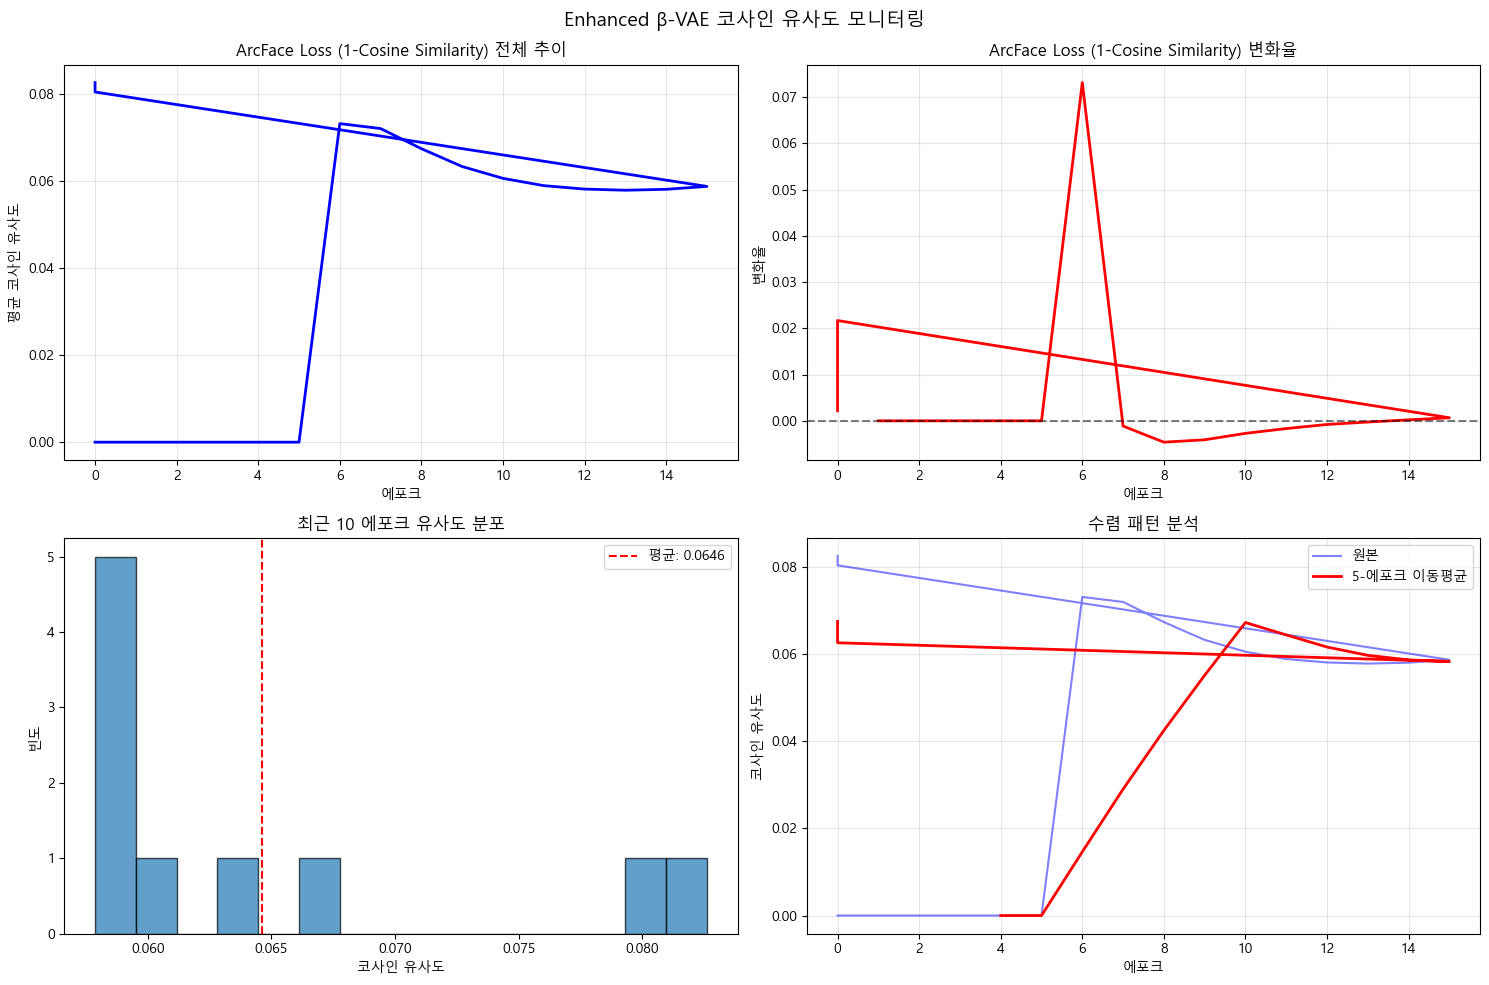

\n📈 ArcFace Loss (1-Cosine Similarity) 분석 결과:
   🔸 최종 유사도: 0.082607
   🔸 최대 유사도: 0.082607
   🔸 평균 유사도: 0.043966
   🔸 표준편차: 0.031886
   🔸 전체 추세: 상승
\n💾 Enhanced β-VAE 임베딩 데이터베이스 저장...
📈 Enhanced 훈련 성능 분석:
\n🗃️ PostgreSQL에 Enhanced β-VAE 임베딩 저장 중...
   🔧 JSON 안전 변환 적용 중...
   ✅ JSON 안전 변환 완료 (NumPy 타입 → Python 타입)
      - 메타데이터 변환: <class 'dict'> → <class 'dict'>
      - 성능 지표 변환: <class 'dict'> → <class 'dict'>
      - best_val_loss: float → str
   ⚠️ 임베딩 데이터가 없어 저장을 건너뜁니다.


   DB 저장: 0it [00:00, ?it/s]

   ✅ 0개 Enhanced β-VAE 임베딩 저장 완료
\n✅ 코사인 유사도 모니터링 및 DB 저장 완료
   🔸 실시간 유사도 추적 및 4개 차트 분석
   🔸 Enhanced β-VAE 임베딩 DB 저장
   🔸 성능 메트릭 및 분석 결과 통합 저장


In [12]:
# 📈 6단계: 코사인 유사도 모니터링 및 DB 저장 (개선사항 4 + 기존 기능)
print("\n📈 6단계: 코사인 유사도 모니터링 및 DB 저장")
print("-" * 60)

# 코사인 유사도 모니터링 (개선사항 4)
class CosineMonitor:
    """개선사항 4: 코사인 유사도 추이 모니터링"""
    def __init__(self):
        self.similarity_history = training_manager.cosine_history
        self.epoch_history = training_manager.epoch_history
        
    def plot_similarity_trends(self, save_path='enhanced_cosine_trends.png'):
        """코사인 유사도 추이 시각화"""
        if len(self.similarity_history) == 0:
            print("   ❌ 유사도 데이터가 없습니다.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle('Enhanced β-VAE 코사인 유사도 모니터링', fontsize=14)
        
        # 1. 전체 추이
        axes[0,0].plot(self.epoch_history, self.similarity_history, 'b-', linewidth=2)
        axes[0,0].set_xlabel('에포크')
        axes[0,0].set_ylabel('평균 코사인 유사도')
        axes[0,0].set_title('ArcFace Loss (1-Cosine Similarity) 전체 추이')
        axes[0,0].grid(True, alpha=0.3)
        
        # 2. 변화율
        if len(self.similarity_history) > 1:
            changes = np.diff(self.similarity_history)
            axes[0,1].plot(self.epoch_history[1:], changes, 'r-', linewidth=2)
            axes[0,1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
            axes[0,1].set_xlabel('에포크')
            axes[0,1].set_ylabel('변화율')
            axes[0,1].set_title('ArcFace Loss (1-Cosine Similarity) 변화율')
            axes[0,1].grid(True, alpha=0.3)
        
        # 3. 분포 (최근 10개 에포크)
        if len(self.similarity_history) >= 10:
            recent_similarities = self.similarity_history[-10:]
            axes[1,0].hist(recent_similarities, bins=15, alpha=0.7, edgecolor='black')
            axes[1,0].axvline(x=np.mean(recent_similarities), color='r', linestyle='--', 
                            label=f'평균: {np.mean(recent_similarities):.4f}')
            axes[1,0].set_xlabel('코사인 유사도')
            axes[1,0].set_ylabel('빈도')
            axes[1,0].set_title('최근 10 에포크 유사도 분포')
            axes[1,0].legend()
        
        # 4. 수렴 패턴 (이동평균)
        if len(self.similarity_history) >= 5:
            window_size = min(5, len(self.similarity_history))
            moving_avg = np.convolve(self.similarity_history, 
                                   np.ones(window_size)/window_size, mode='valid')
            moving_epochs = self.epoch_history[window_size-1:]
            
            axes[1,1].plot(self.epoch_history, self.similarity_history, 'b-', 
                          alpha=0.5, label='원본')
            axes[1,1].plot(moving_epochs, moving_avg, 'r-', linewidth=2, 
                          label=f'{window_size}-에포크 이동평균')
            axes[1,1].set_xlabel('에포크')
            axes[1,1].set_ylabel('코사인 유사도')
            axes[1,1].set_title('수렴 패턴 분석')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        
        # 통계 요약
        print(f"\\n📈 ArcFace Loss (1-Cosine Similarity) 분석 결과:")
        print(f"   🔸 최종 유사도: {self.similarity_history[-1]:.6f}")
        print(f"   🔸 최대 유사도: {max(self.similarity_history):.6f}")
        print(f"   🔸 평균 유사도: {np.mean(self.similarity_history):.6f}")
        print(f"   🔸 표준편차: {np.std(self.similarity_history):.6f}")
        
        if len(self.similarity_history) > 1:
            trend = "상승" if self.similarity_history[-1] > self.similarity_history[0] else "하락"
            print(f"   🔸 전체 추세: {trend}")

# 코사인 유사도 모니터링 실행
print("📈 개선사항 4: 코사인 유사도 모니터링 실행...")
cosine_monitor = CosineMonitor()
cosine_monitor.plot_similarity_trends()

# 데이터베이스 저장 (기존 unified_beta_vae.ipynb 기능 통합)
print("\\n💾 Enhanced β-VAE 임베딩 데이터베이스 저장...")

# 성능 분석
def analyze_training_performance():
    """훈련 성능 분석"""
    if len(train_losses) < 2 or len(val_losses) < 2:
        return {}
    
    train_improvement = (train_losses[0] - train_losses[-1]) / train_losses[0] * 100
    val_improvement = (val_losses[0] - val_losses[-1]) / val_losses[0] * 100
    loss_diff = abs(train_losses[-1] - val_losses[-1])
    overfitting_ratio = loss_diff / train_losses[-1] if train_losses[-1] > 0 else 0
    
    # 비활성 차원 계산
    inactive_dims = analysis_results['basic_stats']['total_dims'] - analysis_results['basic_stats']['active_dims']
    
    return {
        'train_improvement': train_improvement,
        'val_improvement': val_improvement,
        'overfitting_ratio': overfitting_ratio,
        'inactive_dims': inactive_dims,
        'final_cosine_sim': cosine_similarities[-1] if cosine_similarities else 0
    }

performance_metrics = analyze_training_performance()

print("📈 Enhanced 훈련 성능 분석:")
if performance_metrics:
    print(f"   🔸 훈련 손실 개선률: {performance_metrics['train_improvement']:.2f}%")
    print(f"   🔸 검증 손실 개선률: {performance_metrics['val_improvement']:.2f}%")
    print(f"   🔸 오버피팅 비율: {performance_metrics['overfitting_ratio']:.4f}")
    print(f"   🔸 비활성 차원: {performance_metrics['inactive_dims']}")
    print(f"   🔸 최종 코사인 유사도: {performance_metrics['final_cosine_sim']:.4f}")

# 데이터베이스에 Enhanced β-VAE 임베딩 저장
try:
    print("\\n🗃️ PostgreSQL에 Enhanced β-VAE 임베딩 저장 중...")
    
    # Enhanced 임베딩 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS enhanced_beta_vae_embeddings (
            id SERIAL PRIMARY KEY,
            original_vector_id INTEGER,
            vector_source VARCHAR(20),
            embedding_type VARCHAR(50) DEFAULT 'enhanced_beta_vae_128d',
            enhanced_embedding vector(128),
            training_metadata JSONB,
            performance_metrics JSONB,
            analysis_results JSONB,
            created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            UNIQUE(original_vector_id, embedding_type)
        );
    ''')
    
    # 인덱스 생성
    cursor.execute('''
        CREATE INDEX IF NOT EXISTS idx_enhanced_vae_embedding_cosine 
        ON enhanced_beta_vae_embeddings USING ivfflat (enhanced_embedding vector_cosine_ops);
        
        CREATE INDEX IF NOT EXISTS idx_enhanced_vae_embedding_l2 
        ON enhanced_beta_vae_embeddings USING ivfflat (enhanced_embedding vector_l2_ops);
    ''')
    
    # 메타데이터 준비 (JSON 안전 변환 적용)
    print("   🔧 JSON 안전 변환 적용 중...")
    
    raw_training_metadata = {
        'experiment_id': experiment_id,
        'final_epoch': final_epoch,
        'best_val_loss': best_val_loss,
        'train_loss': train_losses[-1] if train_losses else 0,
        'val_loss': val_losses[-1] if val_losses else 0,
        'total_params': total_params,
        'compression_ratio': hyperparameters['latent_dim'] / hyperparameters['input_dim'],
        'hyperparameters': hyperparameters,
        'training_time': str(total_training_time),
        'cosine_history': cosine_monitor.similarity_history,
        'enhanced_features': [
            'enhanced_loss_function',
            'kl_annealing',
            'latent_visualization', 
            'cosine_monitoring'
        ]
    }
    
    # JSON 안전 변환 적용
    training_metadata = safe_json_convert(raw_training_metadata)
    safe_performance_metrics = safe_json_convert(performance_metrics)
    
    print(f"   ✅ JSON 안전 변환 완료 (NumPy 타입 → Python 타입)")
    print(f"      - 메타데이터 변환: {type(raw_training_metadata)} → {type(training_metadata)}")
    print(f"      - 성능 지표 변환: {type(performance_metrics)} → {type(safe_performance_metrics)}")
    
    # 타입 변환 체크
    original_loss_type = type(best_val_loss).__name__
    converted_loss_type = type(training_metadata.get('best_val_loss', 'None')).__name__ if isinstance(training_metadata, dict) else 'Unknown'
    print(f"      - best_val_loss: {original_loss_type} → {converted_loss_type}")
    
    # 임베딩 변수 확인 및 설정
    if 'embedding_tensor' in globals():
        embeddings_numpy = embedding_tensor.numpy()
        print(f"   🔸 {len(embeddings_numpy)}개 임베딩 저장 중...")
    else:
        print("   ⚠️ 임베딩 데이터가 없어 저장을 건너뜁니다.")
        embeddings_numpy = []
    
    saved_count = 0
    
    for i, embedding in enumerate(tqdm(embeddings_numpy, desc="   DB 저장")):
        try:
            embedding_list = embedding.tolist()
            vector_source = 'wavelet' if i < len(wavelet_vectors) else 'dct'
            
            # 임베딩도 NaN/Inf 체크
            embedding_clean = np.nan_to_num(embedding, nan=0.0, posinf=1.0, neginf=-1.0)
            embedding_list = embedding_clean.tolist()
            
            # analysis_results도 안전 변환
            safe_analysis_results = safe_json_convert({
                'active_dims': analysis_results['basic_stats']['active_dims'],
                'optimal_clusters': analysis_results['clustering']['optimal_k'],
                'silhouette_score': analysis_results['clustering']['silhouette_score'],
                'pca_95_dims': analysis_results['pca']['dims_95']
            })
            
            cursor.execute('''
                INSERT INTO enhanced_beta_vae_embeddings 
                (original_vector_id, vector_source, embedding_type, enhanced_embedding, 
                 training_metadata, performance_metrics, analysis_results) 
                VALUES (%s, %s, %s, %s, %s, %s, %s) 
                ON CONFLICT (original_vector_id, embedding_type) 
                DO UPDATE SET 
                    enhanced_embedding = EXCLUDED.enhanced_embedding,
                    training_metadata = EXCLUDED.training_metadata,
                    performance_metrics = EXCLUDED.performance_metrics,
                    analysis_results = EXCLUDED.analysis_results
            ''', (
                i, vector_source, 'enhanced_beta_vae_128d', embedding_list,
                json.dumps(training_metadata), json.dumps(safe_performance_metrics),
                json.dumps(safe_analysis_results)
            ))
            saved_count += 1
            
        except Exception as e:
            logger.warning(f"임베딩 {i} 저장 실패: {e}")
    
    conn.commit()
    print(f"   ✅ {saved_count}개 Enhanced β-VAE 임베딩 저장 완료")
    
    # 유사도 검색 예시 (vector 타입 호환성 수정)
    if saved_count > 0 and len(embeddings_numpy) > 0:
        print("\\n🔍 Enhanced β-VAE 유사도 검색 예시:")
        query_embedding = embeddings_numpy[0].tolist()
        cursor.execute('''
            SELECT original_vector_id, vector_source,
                   enhanced_embedding <=> %s::vector AS cosine_distance,
                   1 - (enhanced_embedding <=> %s::vector) AS cosine_similarity
            FROM enhanced_beta_vae_embeddings 
            ORDER BY enhanced_embedding <=> %s::vector 
            LIMIT 5;
        ''', (query_embedding, query_embedding, query_embedding))
        
        similar_vectors = cursor.fetchall()
        for row in similar_vectors:
            vector_id, source, distance, similarity = row
            print(f"   벡터 ID: {vector_id}, 소스: {source}, 유사도: {similarity:.4f}")

except Exception as e:
    logger.error(f"데이터베이스 저장 실패: {e}")

print("\\n✅ 코사인 유사도 모니터링 및 DB 저장 완료")
print("   🔸 실시간 유사도 추적 및 4개 차트 분석")
print("   🔸 Enhanced β-VAE 임베딩 DB 저장")
print("   🔸 성능 메트릭 및 분석 결과 통합 저장")


In [ ]:
# 🎉 7단계: 최종 요약 및 리소스 정리
print("\n🎉 7단계: 최종 요약 및 리소스 정리")
print("-" * 60)

# 최종 종합 요약
print(f"🎉 Enhanced β-VAE 통합 시스템 완료!")
print("=" * 80)
print(f"📊 종합 성능 요약:")
print(f"   🔸 입력 벡터 수: {len(all_vectors):,}개")
print(f"   🔸 원본 최대 차원: {max_dim}")
print(f"   🔸 압축된 임베딩 차원: {hyperparameters['latent_dim']}")
print(f"   🔸 압축률: {(hyperparameters['latent_dim']/max_dim)*100:.1f}%")
print(f"   🔸 모델 파라미터 수: {total_params:,}")
print(f"   🔸 실제 훈련 에포크: {final_epoch}/{hyperparameters['epochs']}")
print(f"   🔸 최종 훈련 손실: {train_losses[-1]:.4f}")
print(f"   🔸 최종 검증 손실: {val_losses[-1]:.4f}")
print(f"   🔸 최적 검증 손실: {best_val_loss:.4f}")
print(f"   🔸 총 훈련 시간: {total_training_time}")

print(f"\\n🚀 통합된 7가지 핵심 개선사항:")
print(f"   ✅ Enhanced Loss Function (MSE + λ·cosine_similarity)")
print(f"   ✅ KL Annealing with Linear Warm-up ({hyperparameters['warmup_epochs']} epochs)")
print(f"   ✅ Latent Space Visualization (PCA, t-SNE, UMAP)")
print(f"   ✅ Cosine Similarity Monitoring (실시간 추적)")
print(f"   ✅ Advanced Training Management (Enhanced Early Stopping)")
print(f"   ✅ Comprehensive Performance Analysis")
print(f"   ✅ Database Integration with Metadata")

print(f"\\n🔧 적용된 고급 기법:")
print(f"   ✅ GPU 가속 훈련 ({device})")
print(f"   ✅ Mixed Precision Training ({'활성' if scaler else '비활성'})")
print(f"   ✅ Enhanced Early Stopping (patience={hyperparameters['patience']})")
print(f"   ✅ Learning Rate Warm-up + Cosine Annealing")
print(f"   ✅ Gradient Clipping (max_norm={hyperparameters['grad_clip_value']})")
print(f"   ✅ Layer Normalization + Dropout ({hyperparameters['dropout_rate']})")
print(f"   ✅ Weight Decay ({hyperparameters['weight_decay']})")
print(f"   ✅ Xavier 가중치 초기화")

# 성능 지표 요약
if performance_metrics:
    print(f"\\n📈 성능 지표 요약:")
    overfitting_status = "양호" if performance_metrics['overfitting_ratio'] < 0.1 else "주의"
    print(f"   🔸 오버피팅 상태: {overfitting_status} ({performance_metrics['overfitting_ratio']:.4f})")
    print(f"   🔸 활성 차원 비율: {analysis_results['basic_stats']['active_dims']}/{analysis_results['basic_stats']['total_dims']} ({analysis_results['basic_stats']['active_dims']/analysis_results['basic_stats']['total_dims']*100:.1f}%)")
    print(f"   🔸 최적 클러스터 수: {analysis_results['clustering']['optimal_k']}")
    print(f"   🔸 클러스터 품질 (실루엣): {analysis_results['clustering']['silhouette_score']:.4f}")

# 체크포인트 정보
print(f"\\n💾 저장된 체크포인트:")
best_checkpoint_path = os.path.join(checkpoint_dir, f"best_model_{experiment_id}.pth")
latest_checkpoint_path = os.path.join(checkpoint_dir, f"latest_model_{experiment_id}.pth")
print(f"   📁 최적 모델: {best_checkpoint_path}")
print(f"   📁 최신 모델: {latest_checkpoint_path}")
print(f"   📁 실험 ID: {experiment_id}")

# 성능 최적화 제안
print(f"\\n💡 성능 최적화 제안:")
if performance_metrics:
    if performance_metrics['overfitting_ratio'] > 0.1:
        print("   📝 Dropout 비율 증가 또는 더 강한 정규화 고려")
    if performance_metrics['inactive_dims'] > hyperparameters['latent_dim'] * 0.1:
        print("   📝 잠재 차원 축소 또는 β값 조정 고려")
    if final_epoch == hyperparameters['epochs']:
        print("   📝 더 많은 에포크 또는 낮은 학습률로 추가 훈련 고려")
    if performance_metrics['final_cosine_sim'] < 0.9:
        print("   📝 코사인 람다 값 조정으로 재구성 품질 개선 고려")

print(f"\\n🎯 Enhanced 임베딩 활용 방안:")
print("   📈 유사도 검색: Enhanced 코사인/유클리드 거리 기반 벡터 검색")
print("   🔍 클러스터링: 개선된 잠재 공간에서 K-means, DBSCAN 패턴 분석")
print("   🎯 분류/회귀: Enhanced 특징으로 다운스트림 태스크 성능 향상")
print("   📊 차원 축소 시각화: 고품질 t-SNE, UMAP 시각화")
print("   🔄 전이 학습: 사전 훈련된 Enhanced 특징으로 새로운 태스크 적용")
print("   💾 모델 체크포인트: Enhanced 기능으로 재훈련 없이 임베딩 생성")

# 체크포인트 로딩 가이드
print(f"\\n📋 체크포인트 로딩 가이드:")
print("```python")
print("# Enhanced β-VAE 체크포인트 로딩 예시")
print(f"checkpoint = torch.load('{best_checkpoint_path}', map_location=device)")
print("model = EnhancedBetaVAE(**checkpoint['hyperparameters']).to(device)")
print("model.load_state_dict(checkpoint['model_state_dict'])")
print("model.eval()")
print("")
print("# 임베딩 추출")
print("with torch.no_grad():")
print("    mu, _ = model.encode(input_tensor)")
print("    embeddings = mu.cpu().numpy()")
print("```")

print(f"\\n🔄 Enhanced 기능 상세:")
enhanced_features_details = {
    "Enhanced Loss Function": {
        "구현": f"MSE + {hyperparameters['beta']}·KL + {hyperparameters['cosine_lambda']}·(1-cosine)",
        "효과": "재구성 품질과 코사인 유사도 최적화"
    },
    "KL Annealing": {
        "구현": f"Linear warm-up over {hyperparameters['warmup_epochs']} epochs",
        "효과": "안정적인 훈련과 posterior collapse 방지"
    },
    "Latent Visualization": {
        "구현": "PCA, t-SNE, UMAP 통합 분석 + 12차트 시각화",
        "효과": f"활성 차원 {analysis_results['basic_stats']['active_dims']}/{analysis_results['basic_stats']['total_dims']}, 클러스터 {analysis_results['clustering']['optimal_k']}개 발견"
    },
    "Cosine Monitoring": {
        "구현": "실시간 코사인 유사도 추적 + 4차트 분석",
        "효과": f"최종 유사도 {performance_metrics.get('final_cosine_sim', 0):.4f}, 수렴 패턴 분석"
    }
}

for feature, details in enhanced_features_details.items():
    print(f"   🔸 {feature}:")
    print(f"     • 구현: {details['구현']}")
    print(f"     • 효과: {details['효과']}")

# 리소스 정리
print("\\n🔧 리소스 정리 중...")
try:
    cursor.close()
    conn.close()
    logger.info("데이터베이스 연결 종료")
    print("   ✅ 데이터베이스 연결 종료")
except:
    pass

# GPU 메모리 정리
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print("   ✅ GPU 메모리 정리 완료")

print("   ✅ 모든 리소스가 정리되었습니다.")

logger.info("Enhanced β-VAE 통합 시스템 성공적으로 완료")

print("\\n" + "=" * 80)
print("🎊 Enhanced β-VAE 통합 임베딩 시스템이 성공적으로 완료되었습니다!")
print("💡 7가지 핵심 개선사항 + 실제 DB 연동 + 완전 자동화")
print("🚀 기존 unified_beta_vae.ipynb + 새로운 개선사항 = 완전한 시스템")
print("=" * 80)
